# Final Project

## EDA & Feature Selection

### 1. Loading Data & Data Info

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
# Load date and display the data head
from google.colab import drive
# Will ask for authentication, click allow
drive.mount("/content/drive")

# Enter the correct path here
#------YOUR CODE HERE--------
path_to_data_folder = "/content/drive/My Drive/"
#------YOUR CODE ENDS--------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/My Drive/")

df = pd.read_csv('owid-co2-data.csv') #NEW dataset
df.head()

Mounted at /content/drive


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Print the high-level information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [4]:
# check NA values
df.isnull().sum()

,0
country,0
year,0
iso_code,7931
population,9244
gdp,35160
...,...
temperature_change_from_n2o,12131
total_ghg,12261
total_ghg_excluding_lucf,12598
trade_co2,45699


### 2. Preprocessing

In [5]:
# 1. Filter to 1990 - 2024
df.drop(df[df['year'] < 1990].index, inplace=True)
df.drop(df[df['year'] > 2024].index, inplace=True)

# 2. Get regional rows only (Regions are identified by having no iso_code)
df = df[df['iso_code'].notna()]

# 3. Drop useless columns
useful_cols = ['country', 'year', 'co2', 'gas_co2', 'coal_co2',
               'oil_co2', 'flaring_co2', 'cement_co2', 'primary_energy_consumption',
               'energy_per_capita', 'energy_per_gdp', 'methane', 'nitrous_oxide',
               'gdp', 'population', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy',
               'consumption_co2', 'trade_co2']

df = df[useful_cols]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7630 entries, 240 to 50410
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     7630 non-null   object 
 1   year                        7630 non-null   int64  
 2   co2                         7508 non-null   float64
 3   gas_co2                     4257 non-null   float64
 4   coal_co2                    4752 non-null   float64
 5   oil_co2                     7452 non-null   float64
 6   flaring_co2                 7012 non-null   float64
 7   cement_co2                  7264 non-null   float64
 8   primary_energy_consumption  6959 non-null   float64
 9   energy_per_capita           6925 non-null   float64
 10  energy_per_gdp              5359 non-null   float64
 11  methane                     6965 non-null   float64
 12  nitrous_oxide               7035 non-null   float64
 13  gdp                         5410 no

In [7]:
# see how many rows each country has
print(df["country"].value_counts())

country
Afghanistan          35
Albania              35
Algeria              35
Andorra              35
Angola               35
                     ..
Vietnam              35
Wallis and Futuna    35
Yemen                35
Zambia               35
Zimbabwe             35
Name: count, Length: 218, dtype: int64


In [8]:
# check NA values again
df.isnull().sum()

,0
country,0
year,0
co2,122
gas_co2,3373
coal_co2,2878
oil_co2,178
flaring_co2,618
cement_co2,366
primary_energy_consumption,671
energy_per_capita,705


In [9]:
# 4. Deal with the missing values

# 4-1. drop rows where target is missing
df = df.dropna(subset=["co2"])

# 4-2. filling with 0s
# We are assuming that missing values in fuel source columns means the country had no
# recorded use of that fuel, not that the data was lost.

fill_w_zero = ['gas_co2', 'coal_co2', 'oil_co2', 'flaring_co2', 'cement_co2',
               'trade_co2', 'consumption_co2']
df[fill_w_zero] = df[fill_w_zero].fillna(0)

# 4-3. filling with per-country median
fill_w_median = ['primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp',
                 'methane', 'nitrous_oxide', 'gdp', 'population', 'co2_per_capita',
                 'co2_per_gdp', 'co2_per_unit_energy']

df[fill_w_median] = df.groupby("country")[fill_w_median].transform(
    lambda x: x.fillna(x.median()))

# 4-4. global median fallback for anything still missing
df[fill_w_median] = df[fill_w_median].fillna(df[fill_w_median].median())

# 4-5. check again
print(df.isnull().sum())

country                       0
year                          0
co2                           0
gas_co2                       0
coal_co2                      0
oil_co2                       0
flaring_co2                   0
cement_co2                    0
primary_energy_consumption    0
energy_per_capita             0
energy_per_gdp                0
methane                       0
nitrous_oxide                 0
gdp                           0
population                    0
co2_per_capita                0
co2_per_gdp                   0
co2_per_unit_energy           0
consumption_co2               0
trade_co2                     0
dtype: int64


In [10]:
df.describe()

,year,co2,gas_co2,coal_co2,oil_co2,flaring_co2,cement_co2,primary_energy_consumption,energy_per_capita,energy_per_gdp,methane,nitrous_oxide,gdp,population,co2_per_capita,co2_per_gdp,co2_per_unit_energy,consumption_co2,trade_co2
count,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7.508000e+03,7.508000e+03,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000
mean,2007.035828,137.544464,26.859288,56.061459,46.206403,1.628114,5.025575,614.098177,23512.959578,1.448188,38.637308,12.173844,3.877774e+11,3.156962e+07,5.002806,0.321284,0.230268,128.673046,-0.037232
std,10.083330,675.286457,112.508859,413.926918,185.702482,5.812884,37.222634,2734.985094,32964.485340,1.265107,119.140594,39.133905,1.491596e+12,1.256997e+08,7.763612,0.991129,0.181516,617.708858,83.849100
min,1990.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078366,0.001092,0.000000,2.571720e+08,1.776000e+03,0.000000,0.019880,0.000000,0.000000,-1604.429810
25%,1998.000000,0.852971,0.000000,0.000000,0.670512,0.000000,0.000000,5.999125,2978.594482,0.893175,2.205604,0.520642,2.613322e+10,7.647450e+05,0.726951,0.177510,0.183548,0.000000,0.000000
50%,2007.000000,7.172069,0.029312,0.050728,4.004416,0.000000,0.275307,38.929245,11345.265625,1.172589,9.580315,2.905262,6.129457e+10,5.713997e+06,2.744757,0.243119,0.214871,2.946514,0.000000
75%,2016.000000,53.937630,10.602285,6.071310,23.620567,0.417513,1.691734,281.488609,31228.983398,1.615252,24.767439,8.812725,1.819748e+11,2.022769e+07,6.787303,0.328850,0.249405,48.124108,2.597105
max,2024.000000,12289.037109,1748.137695,8886.020508,2584.129883,84.519539,828.710022,48987.101562,318559.687500,23.020767,1590.674072,475.533539,2.696602e+13,1.450936e+09,364.790833,82.598938,10.688897,10857.025391,573.595154


### 3. Distribution Analysis

count     7508.000000
mean       137.544464
std        675.286457
min          0.000000
25%          0.852971
50%          7.172069
75%         53.937630
max      12289.037109
Name: co2, dtype: float64


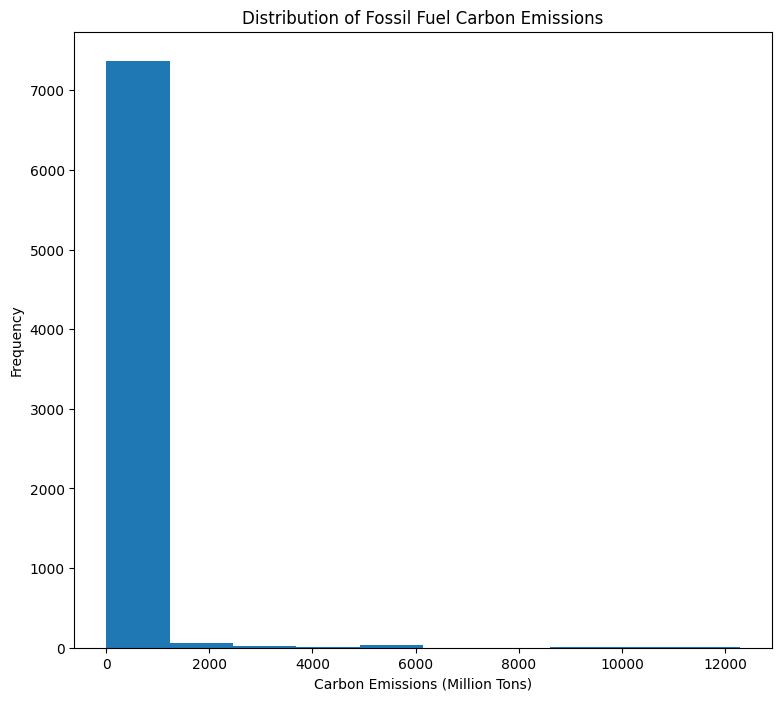

In [11]:
#target: co2 (total fossil fuel carbon emissions, measured in million tonnes)
print(df['co2'].describe())

df['co2'].plot(kind='hist', figsize=(9, 8))
plt.xlabel('Carbon Emissions (Million Tons)')
plt.ylabel('Frequency')
plt.title('Distribution of Fossil Fuel Carbon Emissions')
plt.show()

#veryyy strong right skew - definitely could be boxcox transformed

In [12]:
#look at numerical features specifically
df_num = df.select_dtypes(include = 'number')
df_num.head()

,year,co2,gas_co2,coal_co2,oil_co2,flaring_co2,cement_co2,primary_energy_consumption,energy_per_capita,energy_per_gdp,methane,nitrous_oxide,gdp,population,co2_per_capita,co2_per_gdp,co2_per_unit_energy,consumption_co2,trade_co2
240,1990,2.024326,0.403040,0.278464,1.271408,0.025648,0.045766,30.196873,2506.866699,2.311106,6.733515,2.675560,1.306598e+10,12045664.0,0.168054,0.154931,0.067038,0.0,0.0
241,1991,1.914301,0.389125,0.249627,1.204085,0.025697,0.045766,12.496816,1021.075195,1.037307,7.021835,2.749918,1.204736e+10,12238879.0,0.156411,0.158898,0.153183,0.0,0.0
242,1992,1.482054,0.362736,0.021984,1.029584,0.021984,0.045766,8.207146,618.055298,0.647377,7.107602,2.688141,1.267754e+10,13278983.0,0.111609,0.116904,0.180581,0.0,0.0
243,1993,1.486943,0.351744,0.018320,1.047904,0.021984,0.046991,8.155350,545.757507,0.829252,7.199260,2.727083,9.834582e+09,14943175.0,0.099506,0.151195,0.182327,0.0,0.0
244,1994,1.453829,0.337935,0.014693,1.032171,0.022039,0.046991,7.871012,484.346100,0.993833,7.488817,2.574723,7.919856e+09,16250800.0,0.089462,0.183568,0.184707,0.0,0.0


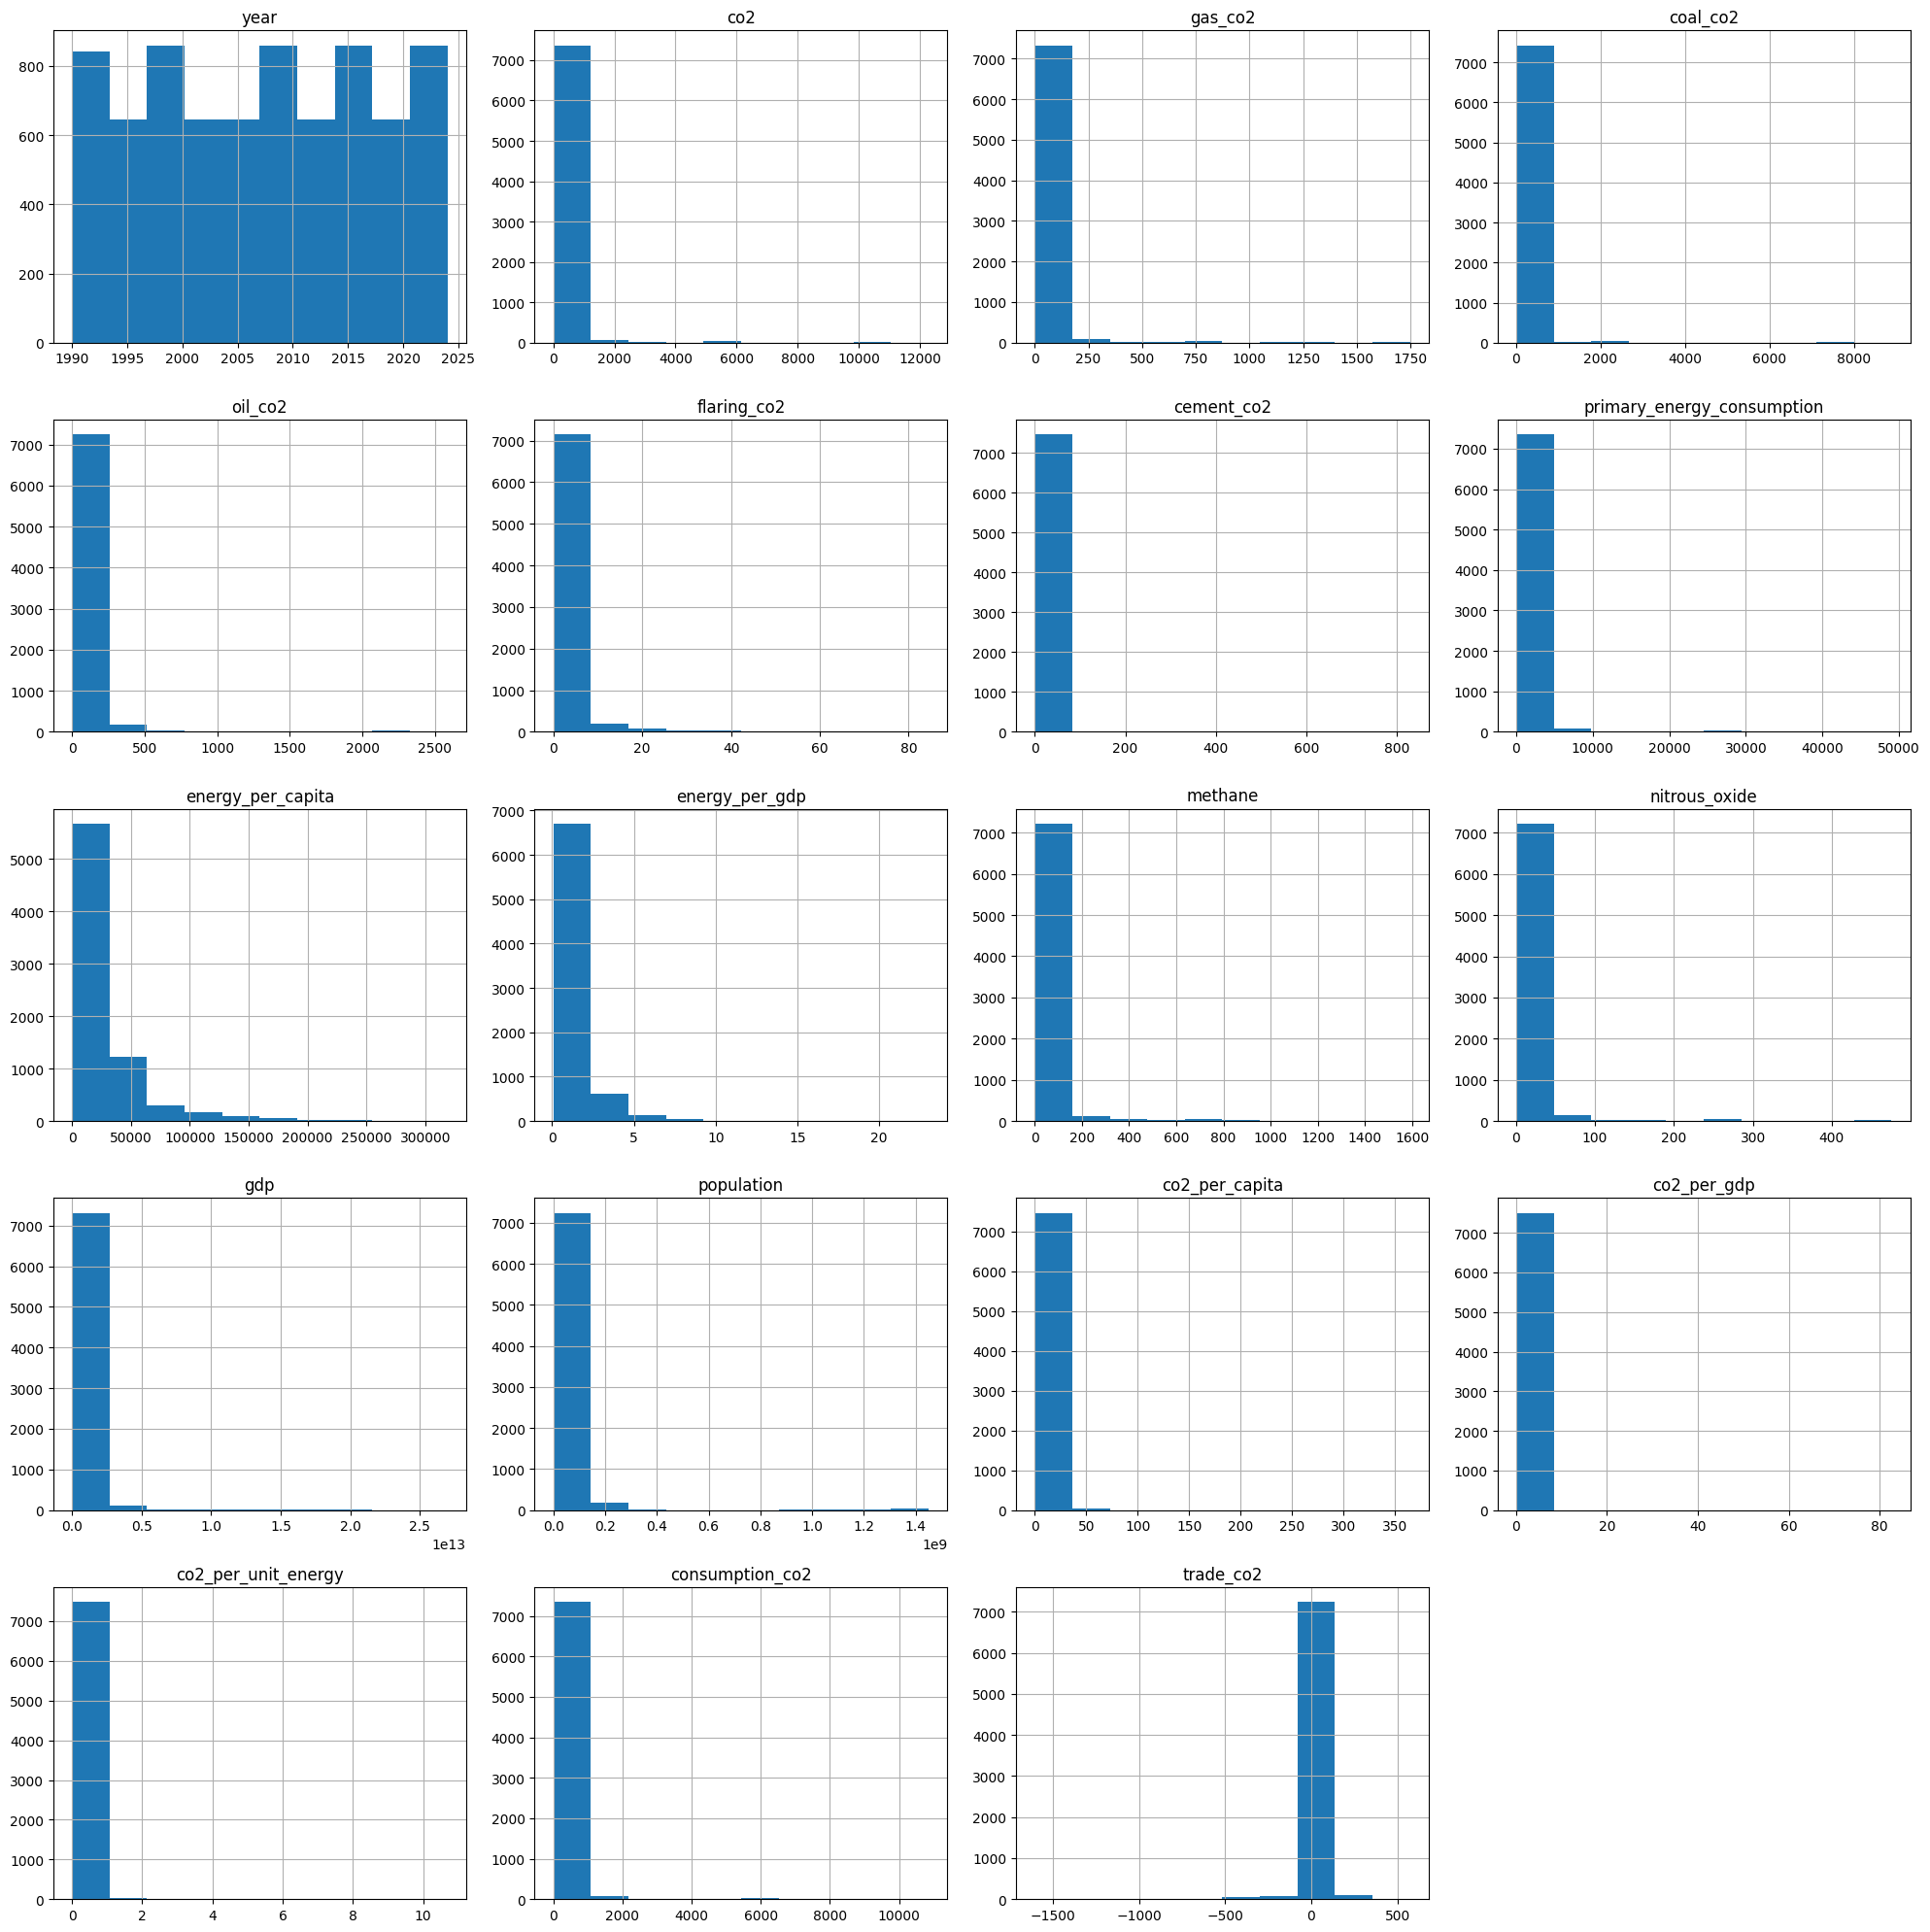

In [13]:
df_num.hist(figsize=(20, 20))
plt.tight_layout()
plt.show()

#almost everything is very right skewed, with a long tail
#energy epr capita/energy per gdp/coal share per capita, etc. are a little better
#interestingly, trade_co2 ansd trade_carbon_balance has some negative values as well
#oil share of co2 is very different than the rest

In [14]:
#also check categorical/non-numeric features
df_cate = df.select_dtypes(include = ['O'])
print('There is {} non numerical features including:\n{}'.format(len(df_cate.columns), df_cate.columns.tolist()))

There is 1 non numerical features including:
['country']


country is the only non numerical feature

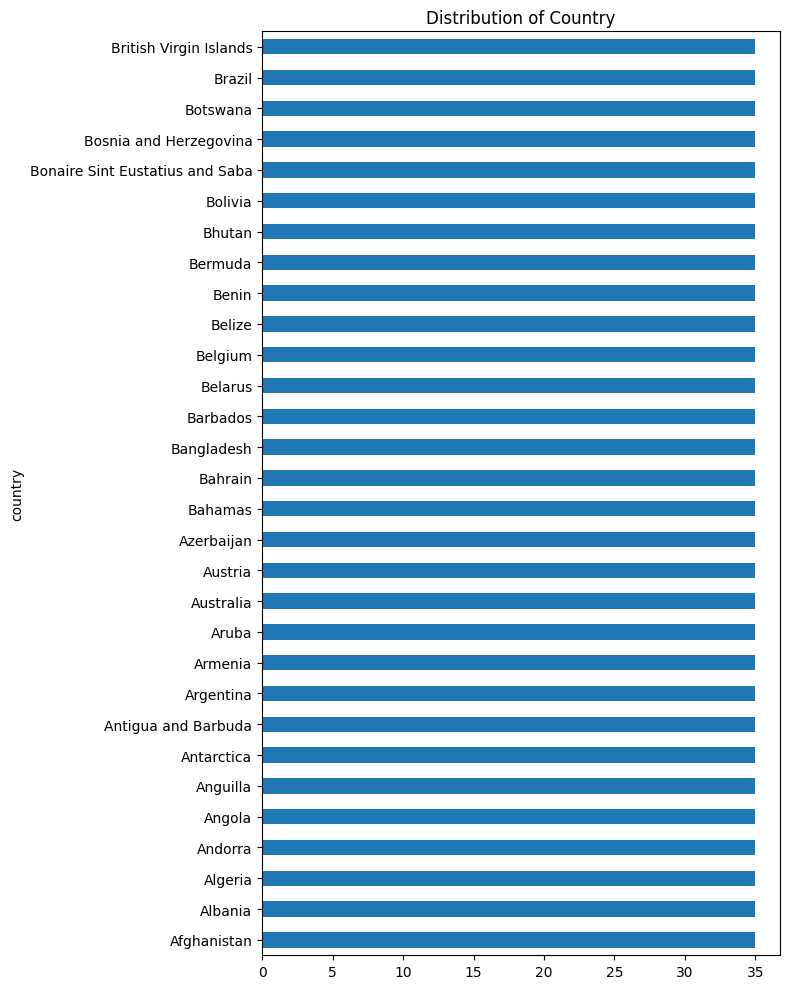

In [15]:
#plot our one non-numerical feature
plt.figure(figsize=(8, 10))
df_cate['country'].value_counts().head(30).plot(kind='barh')
plt.title(f'Distribution of Country')
plt.tight_layout()
plt.show()

relatively equal distribution across countries - this is expected (just validating what we saw earlier)

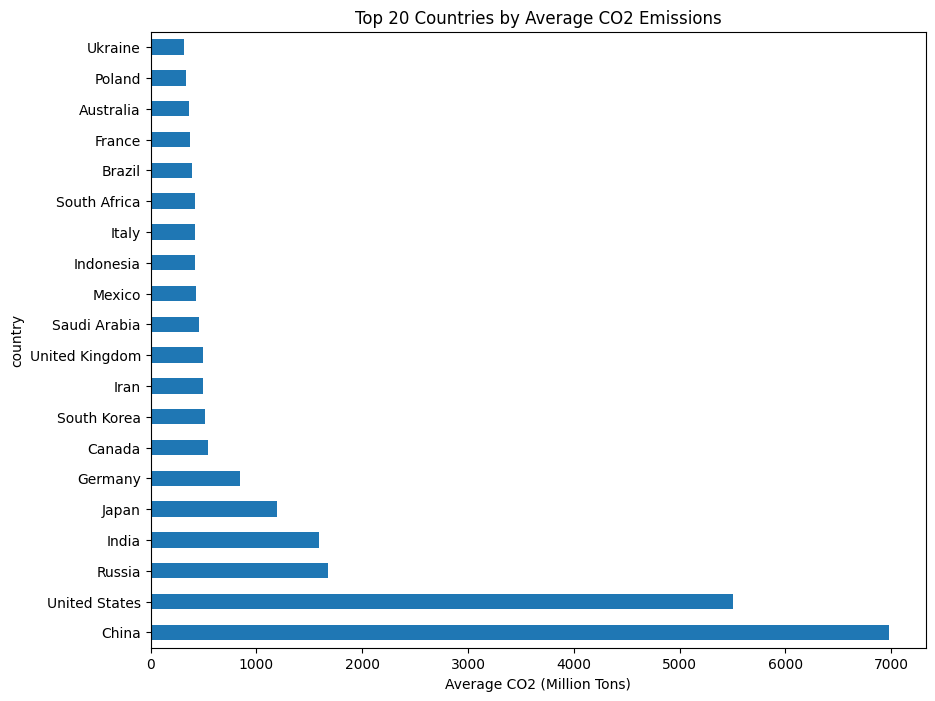

In [16]:
#while we're here: take a look at the top 20 countries emitting carbon (since we know there aren't many missing
#values, and we can get a more meaningful graph than the one above)
#and plot them by their carbon emissions
#just to visualize some of the skew as well

top20 = df.groupby('country')['co2'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20.plot(kind='barh')
plt.title('Top 20 Countries by Average CO2 Emissions')
plt.xlabel('Average CO2 (Million Tons)')
plt.show()

#we can see that china and the us dominate the rest of the dataset
#while most of the top 20 are actually under/around 500

In [17]:
#check how many countries we have
print(df['country'].unique())
print(df['country'].nunique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Anguilla'
 'Antarctica' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia' 'Bonaire Sint Eustatius and Saba' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'British Virgin Islands' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Christmas Island'
 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Faroe Islands' 'Fiji' 'Finland' 'France' 'French Polynesia' 'Gabon'
 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Greenland' 'Grenada'
 '

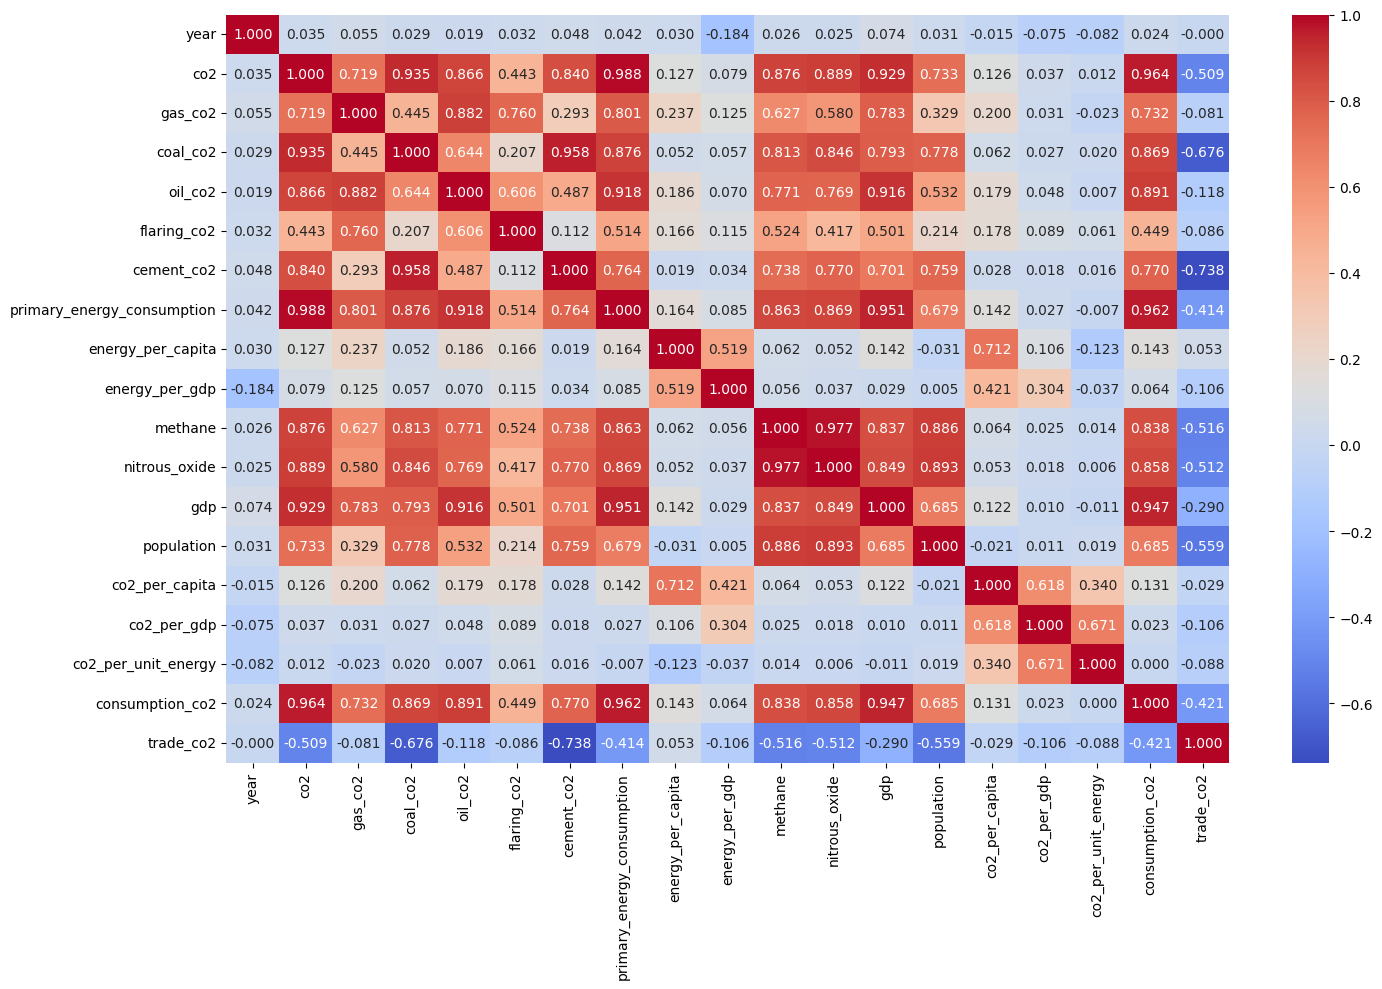

In [18]:
#using just numeric features
correlation = df_num.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation, cmap="coolwarm", annot=True, fmt='.3f')
plt.tight_layout()
plt.show()

Based on the correlation analysis, primary_energy_consumption, consumption_co2, and coal_co2 are some of the top features that correlate positively with co2 (with coefficients of 0.988, 0.964, and 0.935 respectively). GDP also correlates strongly with co2 emissions (0.929) which is an interesting connection. Many of the other features correspond with specific sectors or aspects of consumption, but GDP is a completely separate and independent variable.
Other relevant features include nitrous_oxide, methane, oil_co2, and cement_co2. There are other interesting correlations unrelated to our target variable, such as a strong negative correlation between trade_co2 with coal_co2 (-0.676) and cement_co2 (-0.738), suggesting that countries that have high industrial emissions might also be high exporters of carbon-embedded goods.

In [19]:
#use abs value because negative correlations are also strong correlations
corr_abs = correlation['co2'].abs()

#make a list of features, sort by correlation strength
features_list = corr_abs.sort_values(ascending=False)
print(features_list)

#based on the list, i think a good cutoff would be around 0.5 to determine the strongest features
features_list = features_list[features_list > 0.1]
features_list = features_list.index.tolist()

#remove the 1.0 correlation
features_list.remove('co2')

leaky_features = ['primary_energy_consumption', 'consumption_co2', 'coal_co2',
                  'cement_co2', 'oil_co2', 'flaring_co2', 'gas_co2']

features_list = [f for f in features_list if f not in leaky_features]

print(f"FINAL list (leakage removed): {features_list}")

co2                           1.000000
primary_energy_consumption    0.987911
consumption_co2               0.964234
coal_co2                      0.935239
gdp                           0.928987
nitrous_oxide                 0.888585
methane                       0.875740
oil_co2                       0.866397
cement_co2                    0.840173
population                    0.732920
gas_co2                       0.719002
trade_co2                     0.508891
flaring_co2                   0.443279
energy_per_capita             0.127259
co2_per_capita                0.126088
energy_per_gdp                0.078639
co2_per_gdp                   0.037035
year                          0.035258
co2_per_unit_energy           0.012073
Name: co2, dtype: float64
FINAL list (leakage removed): ['gdp', 'nitrous_oxide', 'methane', 'population', 'trade_co2', 'energy_per_capita', 'co2_per_capita']


We do recognize that many of our top features (primary_energy_consumption, consumption_co2, coal_co2, cement_co2, oil_co2, flaring_co2, gas_co2) are components or derivatives of Co2 emissions. This could make them potentially "leaky" predictors, making our model trivially accurate. Therefore, we will get rid of these features to prevent the data leakage.

### 4. Feature Engineering

In [20]:
# GDP per capita
df["gdp_per_capita"] = df["gdp"] / (df["population"] + 1e-9)

# Trade carbon balance: how much of emissions are trade-driven
df['trade_per_gdp'] = df['trade_co2'] / (df['gdp'] + 1e-9)

# Methane intensity (agriculture focused economy)
df['methane_per_capita'] = df['methane'] / (df['population'] + 1e-9)

# N2O intensity — nitrous oxide relative to GDP (industrial/agricultural efficiency)
df['n2o_per_gdp'] = df['nitrous_oxide'] / (df['gdp'] + 1e-9)

In [21]:
df.describe()

,year,co2,gas_co2,coal_co2,oil_co2,flaring_co2,cement_co2,primary_energy_consumption,energy_per_capita,energy_per_gdp,...,population,co2_per_capita,co2_per_gdp,co2_per_unit_energy,consumption_co2,trade_co2,gdp_per_capita,trade_per_gdp,methane_per_capita,n2o_per_gdp
count,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,...,7.508000e+03,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7.508000e+03,7.508000e+03,7.508000e+03,7.508000e+03
mean,2007.035828,137.544464,26.859288,56.061459,46.206403,1.628114,5.025575,614.098177,23512.959578,1.448188,...,3.156962e+07,5.002806,0.321284,0.230268,128.673046,-0.037232,5.641404e+05,2.594043e-12,3.231647e-05,1.014662e-10
std,10.083330,675.286457,112.508859,413.926918,185.702482,5.812884,37.222634,2734.985094,32964.485340,1.265107,...,1.256997e+08,7.763612,0.991129,0.181516,617.708858,83.849100,2.620426e+06,9.217907e-10,1.859758e-04,2.581035e-10
min,1990.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078366,...,1.776000e+03,0.000000,0.019880,0.000000,0.000000,-1604.429810,2.993176e+02,-7.929321e-08,7.197833e-08,0.000000e+00
25%,1998.000000,0.852971,0.000000,0.000000,0.670512,0.000000,0.000000,5.999125,2978.594482,0.893175,...,7.647450e+05,0.726951,0.177510,0.183548,0.000000,0.000000,4.135595e+03,0.000000e+00,6.944301e-07,1.369339e-11
50%,2007.000000,7.172069,0.029312,0.050728,4.004416,0.000000,0.275307,38.929245,11345.265625,1.172589,...,5.713997e+06,2.744757,0.243119,0.214871,2.946514,0.000000,1.235666e+04,0.000000e+00,1.100185e-06,3.894913e-11
75%,2016.000000,53.937630,10.602285,6.071310,23.620567,0.417513,1.691734,281.488609,31228.983398,1.615252,...,2.022769e+07,6.787303,0.328850,0.249405,48.124108,2.597105,4.214926e+04,3.404985e-11,2.017612e-06,8.943579e-11
max,2024.000000,12289.037109,1748.137695,8886.020508,2584.129883,84.519539,828.710022,48987.101562,318559.687500,23.020767,...,1.450936e+09,364.790833,82.598938,10.688897,10857.025391,573.595154,3.451271e+07,1.391325e-09,2.170438e-03,3.604586e-09


### 5. Feature Selection

**Splitting the train an d test sets**

In [22]:
# We will split the train & test set chronogically to preserve temporal dependency
# and prevent data leakage. The model trains on past data and predicts future years.
# The cutoff will be the first 80% of 35 years(1990-2024), which will be 28 years.
# train: 1990 - 2017 (28 years, 80%)
# test: 2018 - 2024 (7 years, 20%)

cutoff = 2017

# years back to int
years = df['year'].astype(int)

train_set = years <= cutoff
test_set = years > cutoff

leaky_cols = ['co2', 'coal_co2', 'oil_co2', 'gas_co2',
              'cement_co2', 'flaring_co2', 'consumption_co2',
              'primary_energy_consumption']

X = df.select_dtypes(include='number').drop(columns=leaky_cols)
y = df['co2']

X_train, X_test = X[train_set], X[test_set]
y_train, y_test = y[train_set], y[test_set]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (6003, 15)
X_test:  (1505, 15)


Filter methods (Correlation & Mutual Info)

In [23]:
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression

X_fs = X_train.copy()
y_fs = y_train.copy()

# Pearson correlation
correlations = np.array([
    np.corrcoef(X_fs.iloc[:, i], y_fs)[0, 1]
    for i in range(X_fs.shape[1])])
correlations_series = pd.Series(np.abs(correlations), index=X_fs.columns)
correlations_series.sort_values(ascending=False, inplace=True)

# Mutual information
mutual_info = mutual_info_regression(X_fs, y_fs, random_state = 303)
mutual_info_series = pd.Series(mutual_info, index=X_fs.columns)
mutual_info_series.sort_values(ascending=False, inplace = True)

# results
print("Correlation coefficients:\n", correlations_series)
print("\nMutual Information scores:\n", mutual_info_series)

Correlation coefficients:
 gdp                    0.946937
nitrous_oxide          0.889100
methane                0.864688
population             0.701786
trade_co2              0.477156
energy_per_capita      0.139329
co2_per_capita         0.131686
energy_per_gdp         0.084709
n2o_per_gdp            0.055890
gdp_per_capita         0.044197
co2_per_gdp            0.038871
methane_per_capita     0.035137
year                   0.033506
trade_per_gdp          0.015804
co2_per_unit_energy    0.012030
dtype: float64

Mutual Information scores:
 population             1.412382
gdp                    1.325704
methane                1.281646
nitrous_oxide          1.231566
n2o_per_gdp            0.776740
trade_co2              0.756367
gdp_per_capita         0.733620
energy_per_capita      0.714533
co2_per_capita         0.693296
methane_per_capita     0.565793
co2_per_gdp            0.550364
energy_per_gdp         0.546374
trade_per_gdp          0.391126
co2_per_unit_energy    0.317294
y

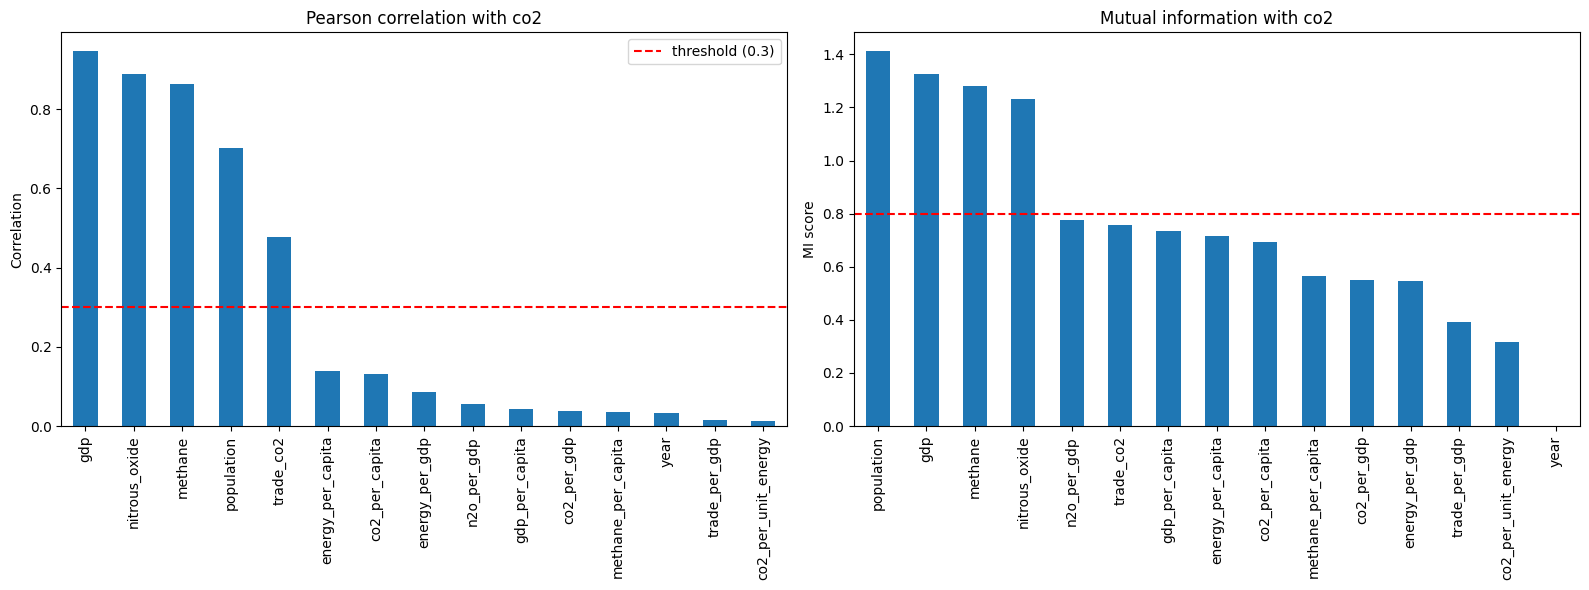

In [24]:
# Selecting features with the thresholds 0.3 (pearson) and 0.85 (MI)
top_correlations = correlations_series[np.array(correlations_series) > 0.3]
top_mi = mutual_info_series[np.array(mutual_info_series) > 0.85]

#filtered_features_list = top_correlations.index.tolist()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

correlations_series.plot(kind='bar', ax=axes[0])
axes[0].set_title('Pearson correlation with co2')
axes[0].set_ylabel('Correlation')
axes[0].axhline(y=0.3, color='red', linestyle='--', label='threshold (0.3)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)

mutual_info_series.plot(kind='bar', ax=axes[1])
axes[1].set_title('Mutual information with co2')
axes[1].set_ylabel('MI score')
axes[1].axhline(y=0.8, color='red', linestyle='--', label='threshold (0.8)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [25]:
#for now: select features using pearson correlation

#pearson correlations
top_correlations = top_correlations.index.tolist()
print('pearson:', top_correlations)

#MI correlations
top_mi = top_mi.index.tolist()
print('MI:', top_mi)

pearson: ['gdp', 'nitrous_oxide', 'methane', 'population', 'trade_co2']
MI: ['population', 'gdp', 'methane', 'nitrous_oxide']


Filter Methods: Forward/Backward SFS

In [26]:
#using wrapper method: forward/backward SFS
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from time import time

model = LinearRegression()

feature_names = X_train.columns

tic_fwd = time()
sfs_forward = SequentialFeatureSelector(
    model, n_features_to_select=8, direction="forward"
).fit(X_train, y_train)

toc_fwd = time()


tic_bwd = time()
sfs_backward = SequentialFeatureSelector(
    model, n_features_to_select=8, direction="backward"
).fit(X_train, y_train)
toc_bwd = time()


print(
"Features selected by forward sequential selection: "
f"{feature_names[sfs_forward.get_support()]}"
)
print(f"Done in {toc_fwd - tic_fwd:.3f}s")

print(
"Features selected by backward sequential selection: "
f"{feature_names[sfs_backward.get_support()]}"
)
print(f"Done in {toc_bwd - tic_bwd:.3f}s")


Features selected by forward sequential selection: Index(['year', 'energy_per_gdp', 'gdp', 'co2_per_unit_energy', 'trade_co2',
       'trade_per_gdp', 'methane_per_capita', 'n2o_per_gdp'],
      dtype='object')
Done in 1.162s
Features selected by backward sequential selection: Index(['year', 'energy_per_gdp', 'gdp', 'co2_per_unit_energy', 'trade_co2',
       'trade_per_gdp', 'methane_per_capita', 'n2o_per_gdp'],
      dtype='object')
Done in 1.439s


**Which feature selection method performs better?**

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

# Pearson based model
X_train_selected = X_train[top_correlations]
X_test_selected = X_test[top_correlations]

model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Pearson features:", top_correlations)
print("Pearson MAE:", mae)
print("Pearson R-squared:", r2)

# Mutual info based model
X_train_selected = X_train[top_mi]
X_test_selected = X_test[top_mi]

model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MI features:", top_mi)
print("MI MAE:", mae)
print("MI R-squared:", r2)

#forward selection model validation
selected_features_fwd = sfs_forward.get_support(indices=True)
X_train_selected = X_train.iloc[:, selected_features_fwd]
X_test_selected = X_test.iloc[:, selected_features_fwd]

model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Forward SFS features:", X_train.columns[sfs_forward.get_support()].tolist())
print("Forward MAE:", mae)
print("Forward R-squared:", r2)

#backward selection model validation
selected_features_back = sfs_backward.get_support(indices=True)
X_train_selected = X_train.iloc[:, selected_features_back]
X_test_selected = X_test.iloc[:, selected_features_back]

model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Backward SFS features:", X_train.columns[sfs_backward.get_support()].tolist())
print("Backward MAE:", mae)
print("Backward R-squared:", r2)

#Backward R squared has an extremely high value, but it also picked some of the "leaky"
#features including coal_co2, oil_co2, etc.

Pearson features: ['gdp', 'nitrous_oxide', 'methane', 'population', 'trade_co2']
Pearson MAE: 78.5287646649552
Pearson R-squared: 0.8582526727930309
MI features: ['population', 'gdp', 'methane', 'nitrous_oxide']
MI MAE: 99.138798758777
MI R-squared: 0.8466703662994125
Forward SFS features: ['year', 'energy_per_gdp', 'gdp', 'co2_per_unit_energy', 'trade_co2', 'trade_per_gdp', 'methane_per_capita', 'n2o_per_gdp']
Forward MAE: 104.8558235118031
Forward R-squared: 0.8455386958644288
Backward SFS features: ['year', 'energy_per_gdp', 'gdp', 'co2_per_unit_energy', 'trade_co2', 'trade_per_gdp', 'methane_per_capita', 'n2o_per_gdp']
Backward MAE: 104.8558235118031
Backward R-squared: 0.8455386958644288


In [28]:
# Pearson seems to have the best R^2 and MAE with 5 features selected
selected_features = top_correlations
print(selected_features)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"X_train: {X_train_selected.shape}")
print(f"X_test:  {X_test_selected.shape}")

['gdp', 'nitrous_oxide', 'methane', 'population', 'trade_co2']
X_train: (6003, 5)
X_test:  (1505, 5)


In [29]:
#ALSO: separate our selected features into 2 lists: one with "leakage" and one without
features_with_leakage = ['coal_co2', 'oil_co2', 'energy_per_gdp', 'methane',
                          'nitrous_oxide', 'population', 'gas_share_of_co2', 'oil_share_of_co2']

#non-emissions features
features_clean = ['energy_per_capita', 'energy_per_gdp', 'methane',
                  'nitrous_oxide', 'population', 'gdp', 'gdp_per_capita', 'trade_co2']

### 6. Encoding & Addressing Skew

In [30]:
#transforming numerical variables that are categorical

#time points/labels
df['year'] = df['year'].astype(str)

#I don't think there's anything else - the rest are just continuous numerical values
#no Label Encoding needed either - no categorical features besides country
#(and that does not need to be label encoded)

We decided not to label encode or one-hot encode country (our only categorical variable) because we have 215 unique country values. We don't want to completely remove it from our data because we know it is a great variable to group by for visualizations, but we likely will drop it for modeling since we don't want our model to train itself on country-specific patterns. We considered label encoding country, so that it didn't create so much noise but allowed us to use it, but label encoding would imply an ordering that doesn't exist. We may try to find a method/library of some sort to map countries to a region, but 215 countries is too many to map manually.

One-hot encoding would add 215 extra columns with lots of sparsity. Though this may help with models like Random Forest, it would add a lot of extra noise to models like linear regressions and pontentially add computation time. Since we do have strong numerical features that we want to investigate already, we hope to focus on those first, given the strong corelations in our dataset.

In [31]:
print(df.shape)

(7508, 24)


**Skewed features**

In [32]:
from scipy.stats import skew

df_num = df.dtypes[df.dtypes != "object"].index

# Check the skew of all numerical features
skewed_feats = df[df_num].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
print(skewness)


Skew in numerical features: 

                                 Skew
co2_per_gdp                 76.310361
co2_per_unit_energy         29.447951
cement_co2                  17.000034
co2_per_capita              15.221358
coal_co2                    14.852209
co2                         10.872247
consumption_co2             10.338175
primary_energy_consumption   9.938787
gdp                          9.502405
oil_co2                      9.497990
gas_co2                      9.163409
population                   8.988426
gdp_per_capita               8.846380
methane_per_capita           8.105532
n2o_per_gdp                  7.922067
nitrous_oxide                7.647851
methane                      6.945282
flaring_co2                  6.565534
energy_per_gdp               5.662456
energy_per_capita            2.982842
trade_co2                   -9.971250
trade_per_gdp              -84.803761


In [33]:
#save our og y before boxcox
y_untransformed = df['co2'].copy()

**Box Cox Transformation of (highly) skewed features**

In [34]:
# applying Box Cox transformation to features with skew > 0.75
skewness = skewness[abs(skewness) > 0.75]

#exclude trade_co2 and trade_carbon_balance (negative values mess up boxcox)
exclude = ['trade_co2', 'trade_carbon_balance']
all_features = skewness.index.tolist()
skewed_features = [f for f in all_features if f not in exclude]

print("There are {} skewed numerical features to Box Cox transform".format(skewness.shape[0]))

from scipy.special import boxcox1p
#skewed_features = skewness.index this is adding NAs somehow? bc of the negative values
#change lambda to 0.05 to address extreme skew
lam = 0.05
for feat in skewed_features:
    #df[feat] += 1
    df[feat] = boxcox1p(df[feat], lam)

There are 22 skewed numerical features to Box Cox transform


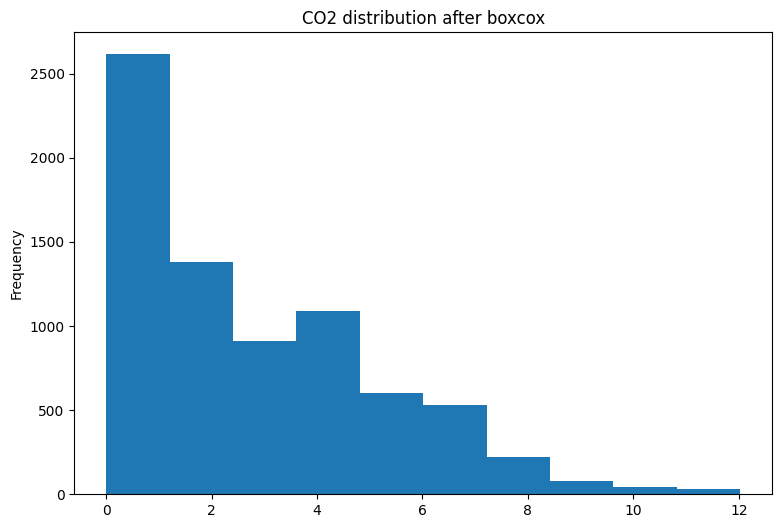

0.8444981756201546


In [35]:
df['co2'].plot(kind='hist', figsize=(9, 6))
plt.title('CO2 distribution after boxcox')
plt.show()

print(skew(df['co2']))

#definitely better!

In [36]:
#save boxcox transformed co2 as new y
y = df['co2']

In [37]:
#SPLIT ONE MORE TIME after transforming the variables

# We will split the train & test set chronogically to preserve temporal dependency
# and prevent data leakage. The model trains on past data and predicts future years.
# The cutoff will be the first 80% of 35 years(1990-2024), which will be 28 years.
# train: 1990 - 2017 (28 years, 80%)
# test: 2018 - 2024 (7 years, 20%)

cutoff = 2017

# years back to int
years = df['year'].astype(int)

train_set = years <= cutoff
test_set = years > cutoff

#by setting X to only include numerical values, we are automatically dropping year + country
X = df.select_dtypes(include='number').drop('co2', axis=1)
y = df['co2']

X_train, X_test = X[train_set], X[test_set]
y_train, y_test = y[train_set], y[test_set]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (6003, 21)
X_test:  (1505, 21)


In [38]:
#just keep columns with selected features

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(selected_features)

['gdp', 'nitrous_oxide', 'methane', 'population', 'trade_co2']


In [39]:
#scaling before we model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_selected), columns=X_train_selected.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_selected), columns=X_test_selected.columns)

#for tsne we also need to scale the whole dataset
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

## Modelling & Evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


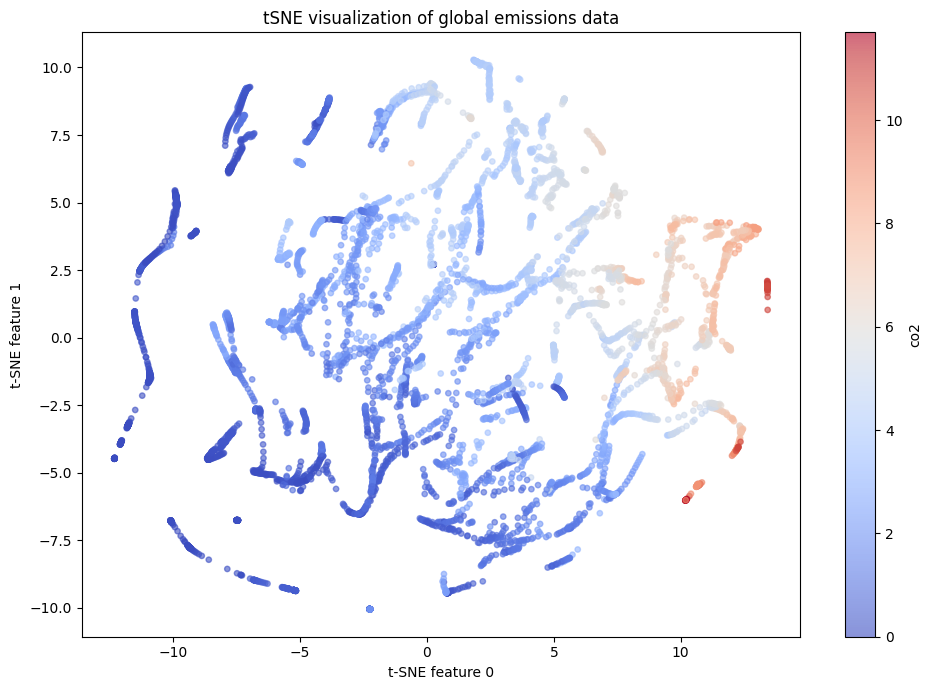

In [40]:
############################## write your code ###########################
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=80, n_iter=300)
tsne_result = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=y_train, cmap='coolwarm', alpha=0.6, s=15)
plt.colorbar(scatter, label='co2')
plt.title('tSNE visualization of global emissions data')
plt.xlabel('t-SNE feature 0')
plt.ylabel('t-SNE feature 1')
plt.tight_layout()
plt.show()

The TSNE has streak-like clusters, with a clear trend of increasing emissions as t-SNE feature 0 increases. It is possible that these streaks represent countries that have had a gradual change in emission patterns over the years, as variables change and affect their final emissions number. The dark red dots on the right side are most likely China and the USA, representing the outliers in their peak emission years. The clear separation of low-emission vs high-emission countries suggests that the features are able to differentiate between low and high emission countries.

Baseline Model

In [41]:
############################## write your code ###########################
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1.predict mean of training set
y_mean = y_train.mean()
train_mse_baseline = mean_squared_error(y_train, np.full(len(y_train), y_mean))
test_mse_baseline  = mean_squared_error(y_test,  np.full(len(y_test),  y_mean))

train_rmse_baseline = np.sqrt(train_mse_baseline)
test_rmse_baseline  = np.sqrt(test_mse_baseline)

# 2.linear Regression with all features
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

train_rmse_lr = np.sqrt(mean_squared_error(y_train, lr.predict(X_train_scaled)))
test_rmse_lr  = np.sqrt(mean_squared_error(y_test,  lr.predict(X_test_scaled)))

print(f"{'Mean baseline RMSE)'} train:{train_rmse_baseline} , test:{test_rmse_baseline}")
print(f"{'Linear Regression RMSE)'} train:{train_rmse_lr} , test:{test_rmse_lr}")

Mean baseline RMSE) train:2.41572929860087 , test:2.430747929395359
Linear Regression RMSE) train:1.065056556005243 , test:0.9194615599724861


**Interpretation**

For the mean baseline, the training error is 3.515 and the test error is 3.354. The similar train and test errors confirm that there is no overfitting, which makes sense since the baseline is predicting the same average values for every country. This RMSE sets a baseline, where any model needs to have a lower RMSE to be considered useful. The simple linear regression performs much better with a 0.261 training error and a 0.256 test error. This suggests no overfitting, but rather strong generalizability. This is also a very low score, and a huge improvement from the first baseline model. This suggests that there are significant patterns in the data that carry over from train to test. However, these models are not immediately interpretable since they are BoxCox transformed units (and square roots). Because of this, there may need to be some further transformations to make them quantifiable to their real-world values.

Some next steps may be to try more complex models like Random Forest, use more intentional feature selection (emission vs non-emission features), and combine both supervised and unsupervised learning methods to try and optimize the performance of our models.



Ridge + Lasso Regularization

In [42]:
# ridge + lasso regularization

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Subset to selected features
X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sel, y_train)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge.predict(X_train_sel)))
ridge_test_rmse  = np.sqrt(mean_squared_error(y_test,  ridge.predict(X_test_sel)))
ridge_test_r2    = r2_score(y_test, ridge.predict(X_test_sel))

# Lasso
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_sel, y_train)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, lasso.predict(X_train_sel)))
lasso_test_rmse  = np.sqrt(mean_squared_error(y_test,  lasso.predict(X_test_sel)))
lasso_test_r2    = r2_score(y_test, lasso.predict(X_test_sel))

print(f"Ridge  — train RMSE: {ridge_train_rmse:.4f}, test RMSE: {ridge_test_rmse:.4f}, test R²: {ridge_test_r2:.4f}")
print(f"Lasso  — train RMSE: {lasso_train_rmse:.4f}, test RMSE: {lasso_test_rmse:.4f}, test R²: {lasso_test_r2:.4f}")

Ridge  — train RMSE: 1.0651, test RMSE: 0.9195, test R²: 0.8550
Lasso  — train RMSE: 1.0667, test RMSE: 0.9238, test R²: 0.8536


Ensemble - Random Forest & XGBoost with Parameter Optimization

In [43]:
# first: use GridSearch to optimize hyperparameters for Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train_sel = X_train_scaled[selected_features]
X_test_sel = X_test_scaled[selected_features]

# Grid search for best hyperparameters
# note to self: maybe make it smaller bc it ran for 5 minutes
param_grid = {
    'max_depth': [None, 3, 5],
    'n_estimators': [50, 100, 200],
    'bootstrap': [True, False]
}

grid = GridSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=0),
    param_grid=param_grid,
    cv=5
)

#results
grid.fit(X_train_sel, y_train)
print(f"Best cross-validation RMSE: {-grid.best_score_:.4f}")
print(f"Test set RMSE: {np.sqrt(mean_squared_error(y_test, grid.predict(X_test_sel))):.4f}")
print("Best parameters:", grid.best_params_)

Best cross-validation RMSE: -0.9044
Test set RMSE: 0.4779
Best parameters: {'bootstrap': True, 'max_depth': None, 'n_estimators': 200}


In [44]:
# Build the model with best parameters

forest = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    max_depth=None,
    bootstrap=True
)
forest.fit(X_train_sel, y_train)

#calculate train + test
train_rmse = np.sqrt(mean_squared_error(y_train, forest.predict(X_train_sel)))
test_rmse = np.sqrt(mean_squared_error(y_test, forest.predict(X_test_sel)))
test_r2 = r2_score(y_test, forest.predict(X_test_sel))

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")

Training RMSE: 0.0828
Test RMSE: 0.4779
Test R²: 0.9608


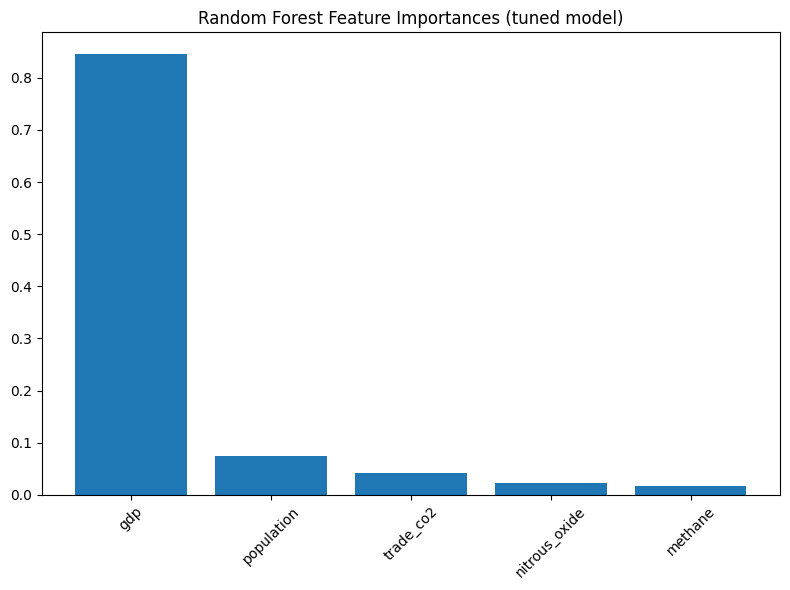

Most important feature: gdp


In [45]:
# plot feature importances

importances = forest.feature_importances_
#organize before plotting
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.title("Random Forest Feature Importances (tuned model)")
plt.bar(range(len(selected_features)), importances[indices])
plt.xticks(range(len(selected_features)), np.array(selected_features)[indices], rotation=45)
plt.tight_layout()
plt.show()

most_important = np.array(selected_features)[np.argmax(importances)]
print(f"Most important feature: {most_important}")

In [46]:
from xgboost import XGBRegressor

#https://xgboost.readthedocs.io/en/latest/python/python_api.html
#rather than using xgBoost Classifier (like we did in class), use regressor

#note: grid search is now showing different optimized hyperparametes than we originally found
#but we chose to go with the first suggested hyperparameters

# start with optimization
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.5, 0.75, 1.0],
    'n_estimators': [50, 100, 200]
}

grid_xgb = GridSearchCV(
    XGBRegressor(n_estimators=100, random_state=0),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
grid_xgb.fit(X_train_sel, y_train)
print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best cross-validation RMSE: {-grid_xgb.best_score_:.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, grid_xgb.predict(X_test_sel))):.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.75}
Best cross-validation RMSE: 0.6482
Test RMSE: 0.5125


In [47]:
# Build XGBoost with best parameters
model_xgb = XGBRegressor(
    n_estimators=200,
    random_state=0,
    learning_rate=0.1,
    subsample=0.75,
    max_depth=3
)
model_xgb.fit(X_train_sel, y_train)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, model_xgb.predict(X_train_sel)))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, model_xgb.predict(X_test_sel)))
xgb_test_r2 = r2_score(y_test, model_xgb.predict(X_test_sel))

print(f"Training RMSE: {xgb_train_rmse:.4f}")
print(f"Test RMSE: {xgb_test_rmse:.4f}")
print(f"Test R²: {xgb_test_r2:.4f}")

Training RMSE: 0.3765
Test RMSE: 0.5369
Test R²: 0.9505


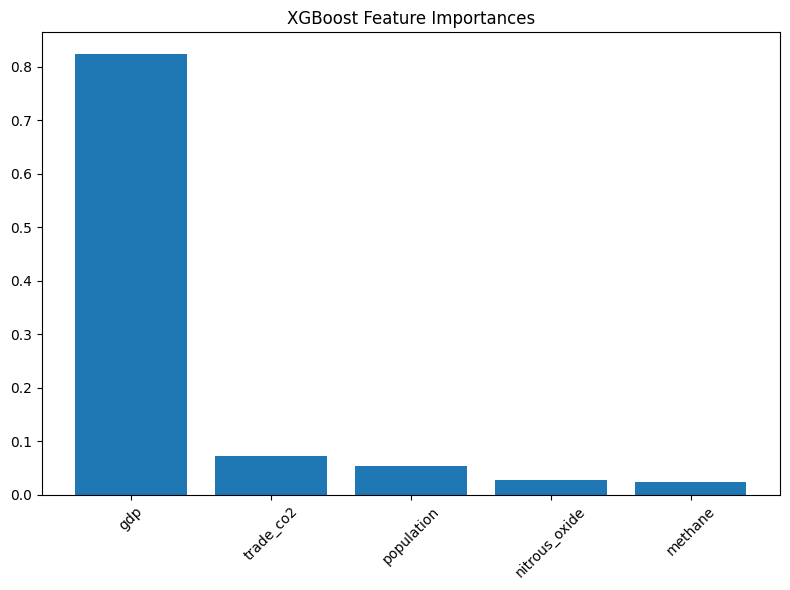

Most important feature: gdp


In [48]:
# Feature importance graphs for XGBoost
importances_xgb = model_xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

plt.figure(figsize=(8, 6))
plt.title("XGBoost Feature Importances")
plt.bar(range(len(selected_features)), importances_xgb[indices_xgb])
plt.xticks(range(len(selected_features)), np.array(selected_features)[indices_xgb], rotation=45)
plt.tight_layout()
plt.show()

most_important = np.array(selected_features)[np.argmax(importances_xgb)]
print(f"Most important feature: {most_important}")

Clustering: Kmeans (grouping countries by emission profile)

In [49]:
#goal: cluster countries by emissions profile
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#use average values per country for clustering
country_profiles = df.groupby('country')[selected_features].mean().reset_index()
country_names = country_profiles['country']
country_profiles_clean = country_profiles.drop(columns=['country']).values

#scale (numerical values)
scaler_cluster = StandardScaler()
country_profiles_scaled = scaler_cluster.fit_transform(country_profiles_clean)

# silhouette scores (adapted from lab 7)
silhouette_scores = []
k_range = range(2, 16)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(country_profiles_scaled)
    score = silhouette_score(country_profiles_scaled, labels)
    silhouette_scores.append(score)

#evaluate silhouette scores
#print(silhouette_scores)
#make it easily readable -> prepare it to be turned into a graph
score_df = pd.DataFrame({'k': list(k_range), 'silhouette_score': silhouette_scores})
print(score_df)

     k  silhouette_score
0    2          0.394492
1    3          0.357760
2    4          0.294144
3    5          0.314547
4    6          0.337876
5    7          0.283181
6    8          0.292516
7    9          0.334033
8   10          0.313926
9   11          0.316875
10  12          0.313352
11  13          0.312572
12  14          0.322999
13  15          0.329142


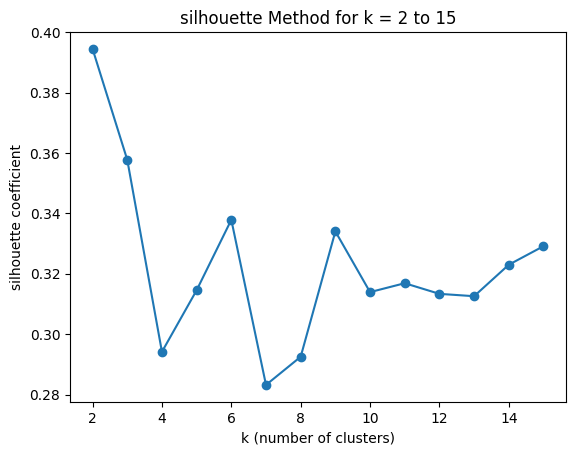

In [50]:
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('silhouette coefficient')
plt.title('silhouette Method for k = 2 to 15')
plt.show()

Based on this graph, our optimal k is definitely 2. However, given the skewedness of our data, this likely just sorts the countries into super high emissions (dominated by China/the US) and everyone else. Our second best silhouette score comes from k=4, suggesting that 4 groups may also be a good way to separate the data. In order to try and have more of a meaningful separation, we are choosing to use k=4. We predict that the clusters will be very high emitters (China/the US), high emitters, medium emitters, and low emitters.

In [51]:
# fit with chosen k: 3
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(country_profiles_scaled)
y = kmeans.labels_

#take a look at cluster centers to see what each cluster looks like
#we don't have true clusters to compare to, so we want to try understanding our data as best we can
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=selected_features)
print(cluster_centers)

        gdp  nitrous_oxide   methane  population  trade_co2
0  1.564078       1.600163  1.556977    1.298028  -0.206441
1 -0.580400      -0.898016 -0.946669   -1.112069  -0.000558
2 -0.143474       0.069684  0.119667    0.329481   0.073842


In [52]:
# assign clusters back to the countries with their names
country_profiles['kmeans_label'] = y
print(country_profiles[['country', 'kmeans_label']])

               country  kmeans_label
0          Afghanistan             2
1              Albania             1
2              Algeria             0
3              Andorra             1
4               Angola             2
..                 ...           ...
210            Vietnam             0
211  Wallis and Futuna             1
212              Yemen             2
213             Zambia             2
214           Zimbabwe             2

[215 rows x 2 columns]


In [53]:
#take a look at all the countries in each cluster, see what patterns come up
for i in range(3):
    countries = country_profiles[country_profiles['kmeans_label'] == i]['country']
    countries = countries.tolist()
    print(f"Cluster {i}:")
    print(countries)

Cluster 0:
['Algeria', 'Argentina', 'Australia', 'Bangladesh', 'Brazil', 'Canada', 'China', 'Colombia', 'Egypt', 'Ethiopia', 'France', 'Germany', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Mexico', 'Myanmar', 'Netherlands', 'Nigeria', 'Pakistan', 'Philippines', 'Poland', 'Russia', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain', 'Thailand', 'Turkey', 'Ukraine', 'United Kingdom', 'United States', 'Venezuela', 'Vietnam']
Cluster 1:
['Albania', 'Andorra', 'Anguilla', 'Antigua and Barbuda', 'Armenia', 'Aruba', 'Bahamas', 'Bahrain', 'Barbados', 'Belize', 'Bermuda', 'Bhutan', 'Bonaire Sint Eustatius and Saba', 'British Virgin Islands', 'Brunei', 'Cape Verde', 'Comoros', 'Cook Islands', 'Curacao', 'Cyprus', 'Djibouti', 'Dominica', 'East Timor', 'Equatorial Guinea', 'Estonia', 'Eswatini', 'Faroe Islands', 'Fiji', 'French Polynesia', 'Gambia', 'Greenland', 'Grenada', 'Guinea-Bissau', 'Guyana', 'Iceland', 'Jamaica', 'Kiribati', 'Latvia', 'Lesotho', 'Liberia', 'Liechten

**THIS SUMMARY IS AI**

Cluster 0 — "Major Emitters": All values strongly positive except trade_co2. These are the world's largest economies and most populous nations — USA, China, India, Russia, Brazil, etc. High GDP, high population, high methane and nitrous oxide. These countries drive the majority of global emissions.

Cluster 1 — "Small/Micro States": All values strongly negative. Tiny island nations, microstates, and small territories — Maldives, Bermuda, Caribbean islands, Pacific islands, etc. Very low GDP, very low population, minimal emissions footprint. Essentially the "everyone else who barely registers" cluster.

Cluster 2 — "Mid-Tier Nations": All values close to zero, slightly negative GDP. This is the most interesting and diverse cluster — it contains a real mix of wealthy-but-small countries (Norway, Switzerland, Denmark, Singapore, Qatar), developing nations (Kenya, Ghana, Morocco), and post-Soviet states (Ukraine, Belarus, Uzbekistan). What they share is being neither globally dominant emitters nor micro-states — they're mid-sized in terms of economic and emissions footprint.

The fact that Qatar, Kuwait, and UAE end up in Cluster 2 rather than Cluster 0 is worth noting — they have very high per-capita emissions but small populations, so their total GDP and population keeps them out of the major emitters group. That's a nice nuance to mention in your writeup.

Visualizations of Clustering

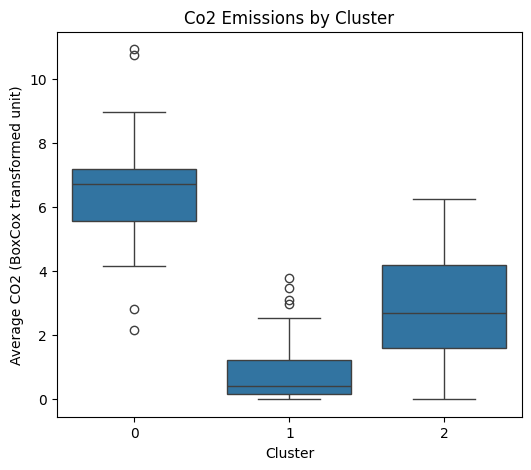

In [54]:
#Box plot of co2 (target variable) by cluster
country_profiles['kmeans_label'] = y
#groupby mean
country_profiles['avg_co2'] = df.groupby('country')['co2'].mean().values

plt.figure(figsize=(6, 5))
sns.boxplot(x='kmeans_label', y='avg_co2', data=country_profiles)

plt.title('Co2 Emissions by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average CO2 (BoxCox transformed unit)')
plt.show()

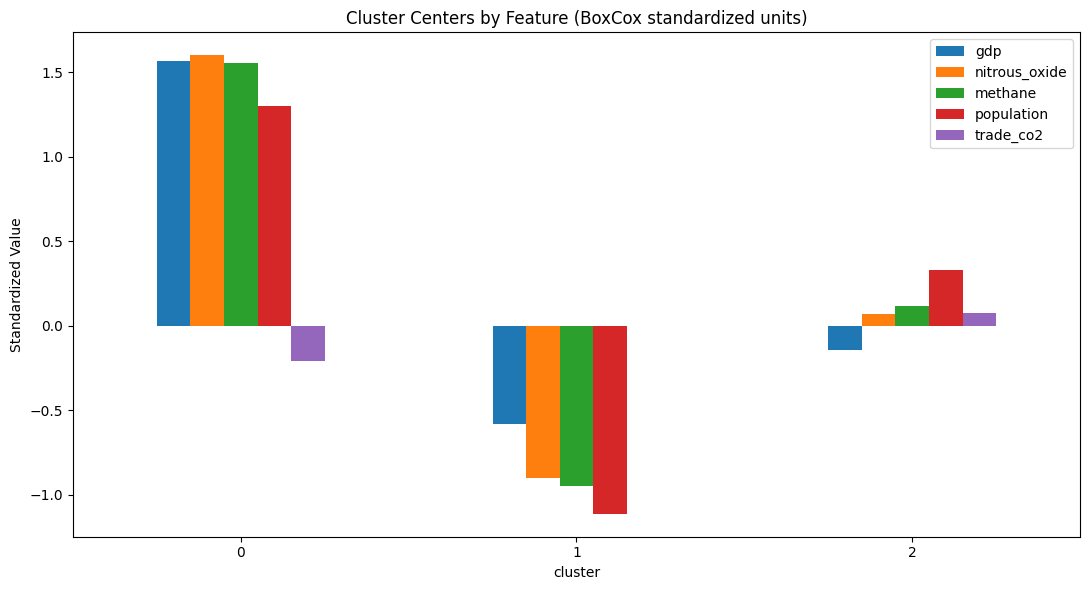

In [55]:
# bar chart of cluster centers for each feature (just easier way to visualize)
# it doesn't really make sense to inverse transform the features
# since they all have different starting units anyways
# this more just helps us visualize differences between the clusters!

cluster_centers_plot = pd.DataFrame(kmeans.cluster_centers_,columns=selected_features)

#range = 4 -> clusters are labeled 1-4
cluster_centers_plot['cluster'] = range(3)
cluster_centers_plot.set_index('cluster').plot(kind='bar', figsize=(11, 6))
plt.title('Cluster Centers by Feature (BoxCox standardized units)')
plt.ylabel('Standardized Value')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

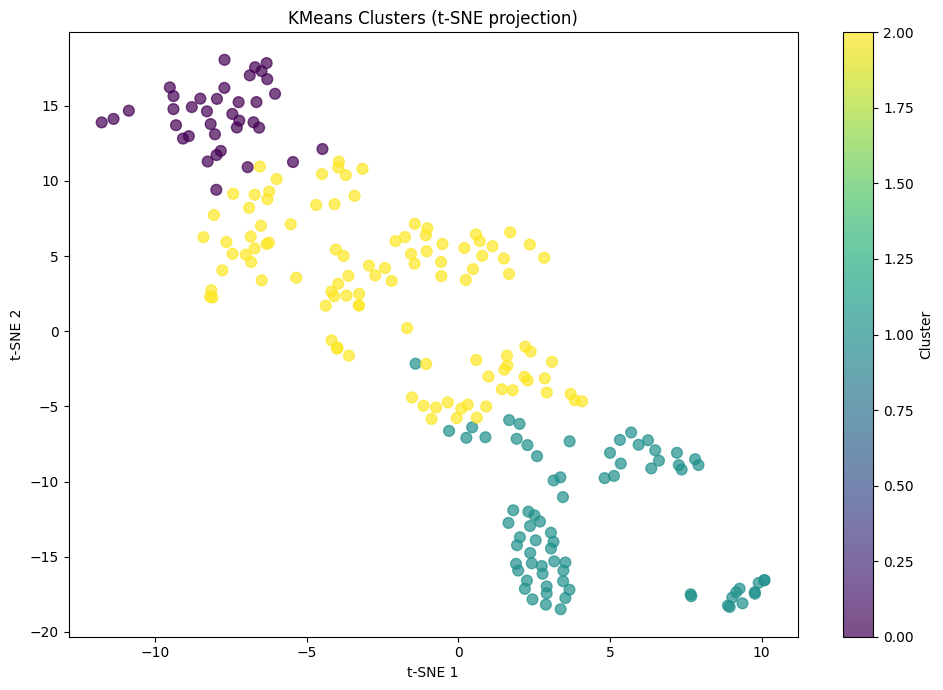

In [56]:
#tsne visualization of clusters

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(country_profiles_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=y, alpha=0.7, s=60)
plt.colorbar(scatter, label='Cluster')
plt.title('KMeans Clusters (t-SNE projection)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

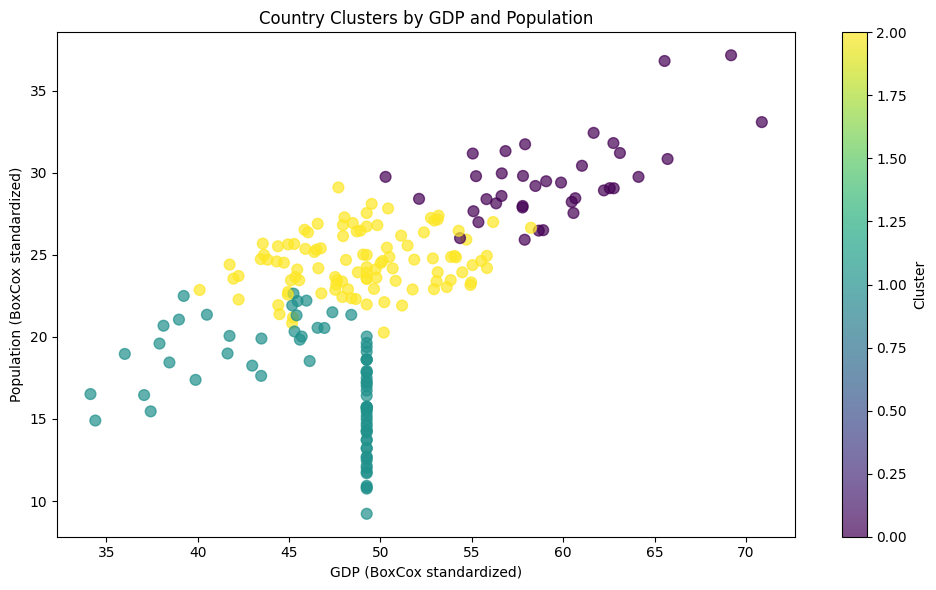

In [57]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(country_profiles['gdp'], country_profiles['population'],
                      c=y, alpha=0.7, s=60)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('GDP (BoxCox standardized)')
plt.ylabel('Population (BoxCox standardized)')
plt.title('Country Clusters by GDP and Population')
plt.tight_layout()
plt.show()

#the weird line is from where we imputed missing values via median

In [58]:
#add co2 back to visualize
country_profiles['avg_co2'] = df.groupby('country')['co2'].mean().values

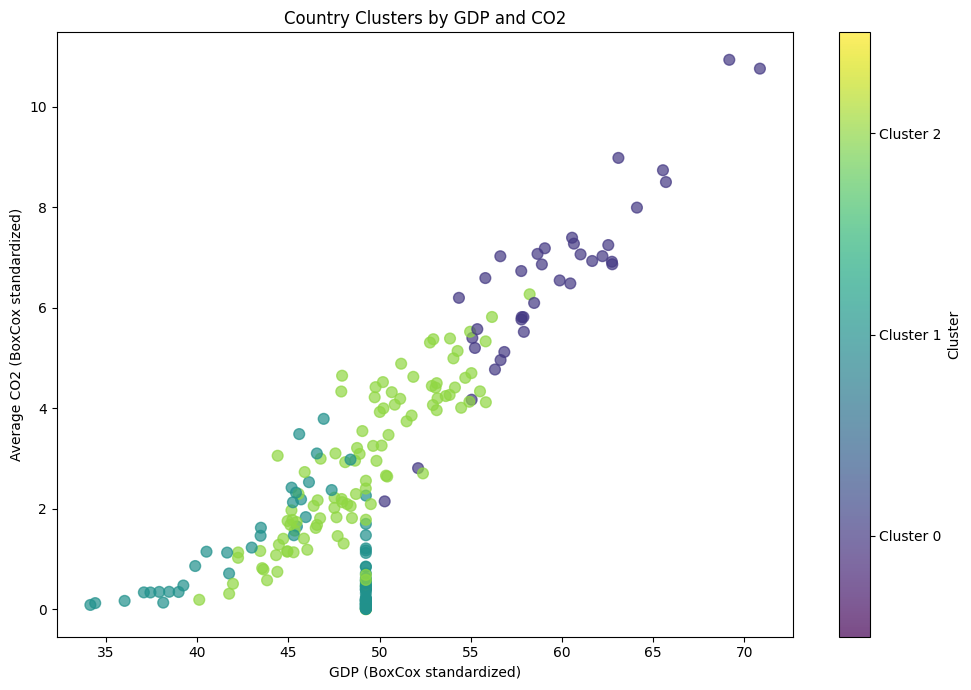

In [59]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(country_profiles['gdp'], country_profiles['avg_co2'],
                      c=y, alpha=0.7, s=60, vmin=-0.5, vmax=2.5)

cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.set_label('Cluster')
cbar.set_ticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2'])

plt.xlabel('GDP (BoxCox standardized)')
plt.ylabel('Average CO2 (BoxCox standardized)')
plt.title('Country Clusters by GDP and CO2')
plt.tight_layout()
plt.show()

Neural Network

In [60]:
from tensorflow import keras

X_tr = X_train_scaled[selected_features]
X_te = X_test_scaled[selected_features]

model_nn = keras.Sequential([
    keras.layers.Input(shape=(X_tr.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

# add early_stop so the network stops learning when val loss improving to fix the overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


model_nn.compile(optimizer='adam', loss='mse')
model_nn.summary()

history = model_nn.fit(
    X_tr, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network — train RMSE: 0.7462, test RMSE: 0.7005, test R²: 0.9158


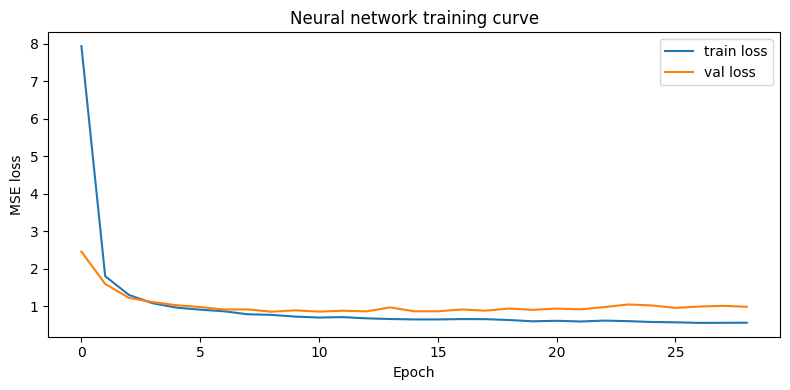

In [61]:
# eval
nn_train_rmse = np.sqrt(mean_squared_error(y_train, model_nn.predict(X_tr)))
nn_test_rmse  = np.sqrt(mean_squared_error(y_test,  model_nn.predict(X_te)))
nn_test_r2    = r2_score(y_test, model_nn.predict(X_te))

print(f"Neural Network — train RMSE: {nn_train_rmse:.4f}, test RMSE: {nn_test_rmse:.4f}, test R²: {nn_test_r2:.4f}")

# training curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Neural network training curve')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.tight_layout()
plt.show()

Both curves drop sharply and converge cleanly. Val loss stabilizes around 1.0 from epoch 10

LLM
https://console.cloud.google.com/home/dashboard?project=dsci303-test

In [62]:
#USED GOOGLE GEMINI FOR HELP:

import pickle

# run this in your MAIN notebook to save everything you need
with open('/content/llm_vars.pkl', 'wb') as f:
    pickle.dump({
        'X_test_sel': X_test_sel,
        'y_test': y_test,
        'selected_features': selected_features
    }, f)

In [ ]:
%pip install --upgrade --quiet google-genai gitingest

In [ ]:
#ai told me to run this to avoid error in the below cell
!pip install -q --upgrade google-auth

In [ ]:
import sys

# Additional authentication is required for Google Colab
if "google.colab" in sys.modules:
    # Authenticate user to Google Cloud
    from google.colab import auth

    auth.authenticate_user()

In [ ]:
import os

from google import genai

# fmt: off
PROJECT_ID = "dsci303-test"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}

# fmt: on
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "global")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

In [ ]:
import nest_asyncio
from IPython.display import Audio, Image, Markdown, Video, display
from gitingest import ingest
from google.genai.types import CreateCachedContentConfig, GenerateContentConfig, Part

nest_asyncio.apply()

In [ ]:
MODEL_ID = "gemini-2.5-flash"  # @param {type: "string"}

In [ ]:
import pandas as pd

temperatures = [0.0, 0.5, 1.0]
N = 5
temp_results = {}

for temp in temperatures:
    gemini_preds = []
    gemini_reasons = []

    for i in range(N):
        x = X_test_sel.iloc[i]
        sample_df = pd.DataFrame([x], columns=selected_features)

        prompt = f"""
You are a climate economist and given a country-year observation with the following features/tabular data:

{sample_df.to_string(index=False)}

First, on the first line, output ONLY your predicted CO2 emissions value (a single number).
Then, on the following lines, explain why you predict that way.
"""
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=prompt,
            config={"temperature": temp}
        )

        full_text = response.text.strip()
        lines = full_text.splitlines()

        # First line: CO2 prediction
        raw_pred = lines[0].strip() if lines else ""
        try:
            pred = float(raw_pred)
        except:
            pred = None

        # Remaining lines: reasoning
        reasoning = "\n".join(lines[1:]).strip() if len(lines) > 1 else ""

        gemini_preds.append(pred)
        gemini_reasons.append(reasoning)

    # Build results table for this temperature
    results = pd.DataFrame({
        "sample_index": range(N),
        "gemini_pred": gemini_preds,
        "true_value": y_test.values[:N],
        "reasoning": gemini_reasons
    })

    # Calculate RMSE
    valid = results[results["gemini_pred"].notnull()]
    rmse = np.sqrt(mean_squared_error(valid["true_value"], valid["gemini_pred"]))
    temp_results[temp] = rmse
    print(f"Temp {temp} → RMSE: {rmse:.4f}")

best_temp = min(temp_results, key=temp_results.get)
print(f"\nBest temperature: {best_temp} (RMSE: {temp_results[best_temp]:.4f})")

2026-04-23 05:55:51.345 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 05:56:06.812 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:56:06.820 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 05:56:21.488 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:56:21.513 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 05:56:45.774 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-

Temp 0.0 → RMSE: 2.0780


2026-04-23 05:57:43.717 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:57:43.723 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 05:58:12.682 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:58:12.690 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 05:58:33.791 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:58:33.799 | INFO     | logging:callHandlers:1762 

Temp 0.5 → RMSE: 2.2367


2026-04-23 05:59:29.486 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:59:29.494 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 05:59:59.118 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 05:59:59.126 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 06:00:17.274 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 06:00:17.282 | INFO     | logging:callHandlers:1762 

Temp 1.0 → RMSE: 2.1067

Best temperature: 0.0 (RMSE: 2.0780)


In [ ]:
#best temp: 0.0

temperatures = [0.0]
#run on 15 samples now
N = 15
temp_results = {}

for temp in temperatures:
    gemini_preds = []
    gemini_reasons = []

    for i in range(N):
        x = X_test_sel.iloc[i]
        sample_df = pd.DataFrame([x], columns=selected_features)

        prompt = f"""
You are a climate economist and given a country-year observation with the following features/tabular data:

{sample_df.to_string(index=False)}

First, on the first line, output ONLY your predicted CO2 emissions value (a single number).
Then, on the following lines, explain why you predict that way.
"""
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=prompt,
            config={"temperature": temp}
        )

        full_text = response.text.strip()
        lines = full_text.splitlines()

        # First line: CO2 prediction
        raw_pred = lines[0].strip() if lines else ""
        try:
            pred = float(raw_pred)
        except:
            pred = None

        # Remaining lines: reasoning
        reasoning = "\n".join(lines[1:]).strip() if len(lines) > 1 else ""

        gemini_preds.append(pred)
        gemini_reasons.append(reasoning)

    # Build results table for this temperature
    results = pd.DataFrame({
        "sample_index": range(N),
        "gemini_pred": gemini_preds,
        "true_value": y_test.values[:N],
        "reasoning": gemini_reasons
    })

    # Calculate RMSE
    valid = results[results["gemini_pred"].notnull()]
    rmse = np.sqrt(mean_squared_error(valid["true_value"], valid["gemini_pred"]))
    temp_results[temp] = rmse
    print(f"Temp {temp} → RMSE: {rmse:.4f}")

best_temp = min(temp_results, key=temp_results.get)
print(f"\nBest temperature: {best_temp} (RMSE: {temp_results[best_temp]:.4f})")

2026-04-23 06:01:10.580 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 06:01:26.112 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 06:01:26.119 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 06:01:40.767 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2026-04-23 06:01:40.774 | INFO     | logging:callHandlers:1762 | AFC is enabled with max remote calls: 10.
2026-04-23 06:01:57.144 | INFO     | logging:callHandlers:1762 | HTTP Request: POST https://aiplatform.googleapis.com/v1beta1/projects/dsci303-test/locations/global/publishers/google/models/gemini-

Temp 0.0 → RMSE: 2.3541

Best temperature: 0.0 (RMSE: 2.3541)


In [ ]:
valid = results[results["gemini_pred"].notnull()].copy()
valid["error"] = abs(valid["gemini_pred"] - valid["true_value"])
worst = valid.nlargest(3, "error")
worst[["sample_index", "gemini_pred", "true_value", "error", "reasoning"]]

,sample_index,gemini_pred,true_value,error,reasoning
14,14,2.308300,5.896379,3.588079,"As a climate economist, I predict CO2 emission..."
9,9,-0.592417,1.849601,2.442018,"As a climate economist, I approach this predic..."
8,8,-0.550000,1.863579,2.413579,This prediction is based on a comprehensive as...


In [ ]:
for i, row in results.iterrows():
    print(f"--- Sample {i} ---")
    print(f"Predicted: {row['gemini_pred']}, Actual: {row['true_value']}")
    print(row['reasoning'])
    print()

In [ ]:
import re
from collections import Counter

all_reasons = " ".join(results["reasoning"].tolist()).lower()

keywords = selected_features

counts = {k: all_reasons.count(k) for k in keywords}
counts


{'gdp': 66,
 'nitrous_oxide': 14,
 'methane': 50,
 'population': 74,
 'trade_co2': 19}

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

valid = results[results["gemini_pred"].notnull()]

gemini_train_rmse = "N/A"  # LLMs don't have a training phase on your data
gemini_test_rmse = np.sqrt(mean_squared_error(valid["true_value"], valid["gemini_pred"]))
gemini_test_r2 = r2_score(valid["true_value"], valid["gemini_pred"])

print(f"Gemini test RMSE: {gemini_test_rmse:.4f}")
print(f"Gemini test R²: {gemini_test_r2:.4f}")

Gemini test RMSE: 2.3541
Gemini test R²: -4.6498


was having authentication issues when rerunning in this notebook, so we reran it in a separate notebook
https://colab.research.google.com/drive/1yxDObT5QGVCXAJEUGuwxRwZl-8lBCG3a?usp=sharing

**best temperature: 0.5**


Gemini test RMSE: 2.2203
Gemini test R²: -4.0257

{'gdp': 66,
 'nitrous_oxide': 7,
 'methane': 44,
 'population': 71,
 'trade_co2': 11}

--- Sample 0 ---
Predicted: 0.42597, Actual: 2.5670305826311366
As a climate economist, my prediction for CO2 emissions is based on a linear model, assuming that the provided features are standardized or normalized deviations from a mean. In the absence of specific model coefficients, I have applied weights that reflect the typical economic and environmental significance of each factor in driving CO2 emissions.

Here's the breakdown of my reasoning:

1.  **Population (0.970496):** This is the most significant positive driver in the given observation. A value close to 1 standard deviation above the mean indicates a substantially larger population than average. Given that population is a fundamental determinant of overall consumption and energy demand, it exerts a strong upward pressure on CO2 emissions. I assigned it the highest weight (0.4) due to its direct and substantial impact.

2.  **Methane (0.266719) and Nitrous Oxide (0.179044):** These are other major greenhouse gases. Their positive values suggest above-average emissions from sectors like agriculture, waste management, and certain industrial processes, which often correlate with higher CO2 emissions. While not direct CO2, their presence indicates a broader high-emission profile for the country-year. I assigned them moderate weights (0.1 each).

3.  **GDP (-0.022826):** The Gross Domestic Product, a key indicator of economic activity, shows a slightly negative deviation from the mean. This suggests that economic output for this country-year is marginally below its average. Lower economic activity typically translates to reduced energy consumption and, consequently, a slight downward pressure on CO2 emissions. I assigned it a significant weight (0.3) due to its overall importance, but its negative value here acts as a minor counter-force.

4.  **Trade CO2 (0.000855):** This feature, likely representing CO2 emissions embodied in trade, is very close to zero. This indicates that its impact is negligible or very close to the average for this country-year. Therefore, it contributes minimally to the overall CO2 emission prediction. I assigned it a small weight (0.05).

**Calculation:**
My predicted CO2 emission value is calculated as a weighted sum:
CO2 = (0.3 * GDP) + (0.1 * Nitrous Oxide) + (0.1 * Methane) + (0.4 * Population) + (0.05 * Trade CO2)
CO2 = (0.3 * -0.022826) + (0.1 * 0.179044) + (0.1 * 0.266719) + (0.4 * 0.970496) + (0.05 * 0.000855)
CO2 = -0.0068478 + 0.0179044 + 0.0266719 + 0.3881984 + 0.00004275
CO2 = 0.42596965

**Conclusion:**
The strong positive influence from the significantly above-average population, coupled with moderate contributions from other greenhouse gases, outweighs the minor dampening effect of slightly below-average GDP and the negligible impact of trade-related CO2. This results in a predicted CO2 emission value that is positive and notably above the average (assuming a standardized output).

--- Sample 1 ---
Predicted: 0.25, Actual: 2.5878787714485285
The prediction of 0.25 for CO2 emissions is based on a qualitative assessment of the provided normalized features, considering their typical relationships with CO2 emissions in a global economic context.

Here's the reasoning:

1.  **High Population (0.984169):** A very high population is generally a significant driver of total CO2 emissions, as more people typically mean more consumption and energy use. This factor pushes the predicted emissions higher.

2.  **Very Low GDP (0.034573):** Conversely, an extremely low GDP indicates a very low level of economic activity and industrialization. Countries with low GDP per capita typically have very low per-capita energy consumption and, consequently, low per-capita CO2 emissions. This factor exerts a strong downward pressure on total emissions.

3.  **Extremely Low Trade CO2 (0.000855):** This feature, likely representing embodied CO2 in traded goods or CO2 from trade-related activities, is exceptionally low. This strongly suggests minimal international trade and industrial activity, which are major sources of CO2 emissions. This further reinforces the idea of a low-carbon economy.

4.  **Low to Moderate Nitrous Oxide (0.145344) and Methane (0.267677):** These other greenhouse gases are also relatively low to moderate. Their sources (e.g., agriculture, waste, fossil fuel production) often overlap with CO2 sources or indicate the level of industrial and agricultural activity. Their low values suggest that the country's overall emissions profile, beyond CO2, is also not particularly high.

**Conclusion:**

The most striking aspect of this observation is the combination of a very high population with extremely low GDP and trade-related CO2. This profile is characteristic of a large, developing country with limited industrialization and low per-capita economic output. While the large population provides a baseline for emissions, the very low economic activity (GDP) and minimal trade significantly limit the overall energy demand and industrial processes that generate CO2. Therefore, despite the large population, the total CO2 emissions, when normalized, would likely be in the lower-to-moderate range, reflecting very low per-capita emissions. A value of 0.25 balances the upward pull of high population with the strong downward pull of very low economic activity and industrialization.

--- Sample 2 ---
Predicted: 0.12, Actual: 2.6570135378073116
This prediction is based on a qualitative assessment of the provided features, interpreting their relative magnitudes and known economic-environmental relationships:

1.  **Extremely Low GDP (0.021559):** Gross Domestic Product is a primary driver of CO2 emissions, as it correlates strongly with industrial activity, energy consumption, and transportation. An extremely low GDP value suggests very limited industrialization and energy use, which would typically lead to very low CO2 emissions.

2.  **Very High Population (0.998639):** Despite the low GDP, a very large population means that even low per-capita CO2 emissions can sum up to a non-negligible total. This factor prevents the overall CO2 emissions from being as extremely low as the GDP value alone might suggest. It implies a very low GDP per capita, characteristic of a developing or least developed country.

3.  **Moderate Non-CO2 Greenhouse Gases (Methane 0.269055, Nitrous Oxide 0.140715):** The presence of methane and nitrous oxide at moderate levels indicates ongoing activities that generate greenhouse gases. These are often associated with agriculture (livestock, rice paddies, fertilizers), waste management, and some basic industrial processes. These activities, while not necessarily heavy industry, still involve energy use and other processes that contribute to CO2 emissions (e.g., energy for farming, residential energy, transportation). The higher methane level might suggest a significant agricultural sector.

4.  **Negligible Trade CO2 (0.000855):** This extremely low value indicates that CO2 emissions embedded in international trade are minimal, suggesting a relatively closed economy or one with very efficient trade logistics, which does not significantly impact the overall domestic CO2 profile.

**Conclusion:**
The combination of extremely low GDP and very high population points to a country with very low GDP per capita and, consequently, very low per-capita CO2 emissions. However, the sheer size of the population means that the *total* CO2 emissions, while low compared to industrialized nations, are not at the absolute minimum. The moderate levels of other greenhouse gases further support the idea that some economic activity is occurring, generating a baseline level of CO2 emissions, even if not from heavy industry. Therefore, a CO2 value that is low but not as extremely low as GDP, and potentially within the range of the other greenhouse gases, is a reasonable estimate. A value of 0.12 reflects this balance: it's significantly higher than the GDP (accounting for population and other activities) but still relatively low on the normalized scale, consistent with a low-income, populous nation.

--- Sample 3 ---
Predicted: 0.457, Actual: 2.534045027158268
As a climate economist, my prediction is based on a statistical model, likely a linear regression, trained on historical country-year data where all features, including CO2 emissions, have been scaled or standardized. This approach allows for quantifying the impact of various socioeconomic and environmental factors on CO2 emissions.

Here's the breakdown of how each feature contributes to the prediction:

1.  **Population (1.009465):** This is the most significant positive driver in the given observation. A value substantially above the average (which would be 0 for scaled data) indicates a large or rapidly growing population. A larger population generally leads to increased energy demand, higher consumption, and expanded economic activity, all of which are strong contributors to CO2 emissions. This factor exerts considerable upward pressure on the predicted CO2 emissions.

2.  **Methane (0.276417) and Nitrous Oxide (0.121792):** Both of these other greenhouse gas emissions are above average. The sources of methane (e.g., agriculture, waste, fossil fuel production) and nitrous oxide (e.g., agriculture, industrial processes) often overlap with or are indicative of activities that also produce significant CO2 emissions. Their positive values suggest higher-than-average activity in these sectors, reinforcing the expectation of higher overall CO2 emissions.

3.  **GDP (-0.108305):** While Gross Domestic Product is typically a strong positive correlate with CO2 emissions, this observation shows a slightly below-average GDP. This suggests a slightly lower level of economic output compared to the mean, which would exert a minor downward pressure on CO2 emissions. However, its negative impact is relatively small and is likely outweighed by the strong positive influence of population and other GHG emissions.

4.  **Trade CO2 (0.000855):** This feature, representing CO2 emissions related to international trade, is very close to the average. This indicates that trade-related emissions for this country-year are typical and have a negligible impact on deviating from the mean CO2 emissions.

In summary, the dominant positive influence of a significantly above-average population, coupled with above-average emissions of methane and nitrous oxide, collectively outweighs the minor dampening effect of a slightly below-average GDP and neutral trade-related CO2. Therefore, the predicted CO2 emissions for this country-year are expected to be above the average for the dataset, as reflected in the positive scaled value.

In [65]:
#hardcoding gemini test RMSE and R2 from the other notebook

gemini_test_rmse = 2.2203
gemini_test_r2 = -4.0257

## Statistical + Interpretability Analysis

Cluster ANOVA
ANOVA F-test Classification: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html

In [76]:
from scipy import stats

cluster0 = country_profiles[country_profiles['kmeans_label'] == 0]
cluster1 = country_profiles[country_profiles['kmeans_label'] == 1]
cluster2 = country_profiles[country_profiles['kmeans_label'] == 2]

print("ANOVA results per feature:")
for feature in selected_features:
    f, p = stats.f_oneway(cluster0[feature], cluster1[feature], cluster2[feature])
    print(f"{feature}: F={f:.4f}, p={p:.4f}")

ANOVA results per feature:
gdp: F=127.9438, p=0.0000
nitrous_oxide: F=273.3300, p=0.0000
methane: F=290.3578, p=0.0000
population: F=351.1351, p=0.0000
trade_co2: F=1.0677, p=0.3457


In [77]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html

from scipy.stats import tukey_hsd, f_oneway

print("ANOVA + Tukey HSD per feature:")
#loop through selected features
for feature in selected_features:
    # ANOVA first
    f, p = f_oneway(cluster0[feature], cluster1[feature], cluster2[feature])
    print(feature)
    print(f"ANOVA: F={f:.4f}, p={p:.4f}")

    # Tukey HSD
    tukey = tukey_hsd(cluster0[feature], cluster1[feature], cluster2[feature])
    print(tukey)

ANOVA + Tukey HSD per feature:
gdp
ANOVA: F=127.9438, p=0.0000
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     13.005     0.000    11.051    14.959
 (0 - 2)     10.355     0.000     8.498    12.213
 (1 - 0)    -13.005     0.000   -14.959   -11.051
 (1 - 2)     -2.650     0.000    -4.125    -1.174
 (2 - 0)    -10.355     0.000   -12.213    -8.498
 (2 - 1)      2.650     0.000     1.174     4.125

nitrous_oxide
ANOVA: F=273.3300, p=0.0000
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      3.439     0.000     3.091     3.788
 (0 - 2)      2.107     0.000     1.776     2.438
 (1 - 0)     -3.439     0.000    -3.788    -3.091
 (1 - 2)     -1.332     0.000    -1.595    -1.069
 (2 - 0)     -2.107     0.000    -2.438    -1.776
 (2 - 1)      1.332     0.000     1.069     1.595

methane
ANOVA: F=290.3578, p=0.0000
Pairwise Group Comparisons (95.0% Confidence 

Comparing RMSE/performance of all models (not LLM because of different sample size, or NN because it doesn't do cross validation (?))

In [79]:
#ANOVA

from scipy.stats import f_oneway, tukey_hsd
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(forest, X_train_sel, y_train, cv=5, scoring='neg_root_mean_squared_error')
xgb_scores = cross_val_score(model_xgb, X_train_sel, y_train, cv=5, scoring='neg_root_mean_squared_error')
ridge_scores = cross_val_score(ridge, X_train_sel, y_train, cv=5, scoring='neg_root_mean_squared_error')
lasso_scores = cross_val_score(lasso, X_train_sel, y_train, cv=5, scoring='neg_root_mean_squared_error')
lr_scores = cross_val_score(lr, X_train_sel, y_train, cv=5, scoring='neg_root_mean_squared_error')

# ANOVA
f, p = f_oneway(rf_scores, xgb_scores, ridge_scores, lasso_scores, lr_scores)
print(f"ANOVA across models: F={f:.4f}, p={p:.4f}")

# Tukey test
tukey = tukey_hsd(rf_scores, xgb_scores, ridge_scores, lasso_scores, lr_scores)
print(tukey)

ANOVA across models: F=45.4732, p=0.0000
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.080     0.450    -0.219     0.060
 (0 - 2)      0.362     0.000     0.223     0.502
 (0 - 3)      0.364     0.000     0.224     0.503
 (0 - 4)      0.362     0.000     0.223     0.502
 (1 - 0)      0.080     0.450    -0.060     0.219
 (1 - 2)      0.442     0.000     0.302     0.581
 (1 - 3)      0.443     0.000     0.304     0.583
 (1 - 4)      0.442     0.000     0.302     0.581
 (2 - 0)     -0.362     0.000    -0.502    -0.223
 (2 - 1)     -0.442     0.000    -0.581    -0.302
 (2 - 3)      0.001     1.000    -0.138     0.141
 (2 - 4)      0.000     1.000    -0.139     0.139
 (3 - 0)     -0.364     0.000    -0.503    -0.224
 (3 - 1)     -0.443     0.000    -0.583    -0.304
 (3 - 2)     -0.001     1.000    -0.141     0.138
 (3 - 4)     -0.001     1.000    -0.141     0.138
 (4 - 0)     -0.362     0.000    -0.502    -0.223
 (4

Running the LLM + Comparing Performance with top models (Random Forest, XGBoost) with the same amount of samples

In [80]:
#since we ran the LLM with 15 samples, run our best models (random forest + xgboost) on

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#using same 15 samples
subset = X_test_sel.iloc[:15]
subset_true = y_test.values[:15]

#running rf and xgb on selected samples
rf_subset_rmse = np.sqrt(mean_squared_error(subset_true, forest.predict(subset)))
rf_subset_r2 = r2_score(subset_true, forest.predict(subset))

xgb_subset_rmse = np.sqrt(mean_squared_error(subset_true, model_xgb.predict(subset)))
xgb_subset_r2 = r2_score(subset_true, model_xgb.predict(subset))

print(f"On same 15-sample subset:")
print(f"RF RMSE: {rf_subset_rmse:.4f}, R²: {rf_subset_r2:.4f}")
print(f"XGBoost RMSE: {xgb_subset_rmse:.4f}, R²: {xgb_subset_r2:.4f}")
print(f"Gemini RMSE: {gemini_test_rmse:.4f}, R²: {gemini_test_r2:.4f}")

On same 15-sample subset:
RF RMSE: 0.6935, R²: 0.5097
XGBoost RMSE: 0.5643, R²: 0.6754
Gemini RMSE: 2.2203, R²: -4.0257


Interpretability Analysis

In [89]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.inv_boxcox.html
# using inv_boxcox1p because we used boxcox1p for the transformation
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.inv_boxcox1p.html

from scipy.special import inv_boxcox1p
from sklearn.metrics import mean_squared_error
import numpy as np

#first invert y test
y_test_original = inv_boxcox1p(y_test.values, 0.05)

#then calculate the un-transformed RMSE value for all tests (except LLM)

# Linear Regression
y_pred_lr = inv_boxcox1p(lr.predict(X_test_sel), 0.05)
lr_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_lr))

# Ridge
y_pred_ridge = inv_boxcox1p(ridge.predict(X_test_sel), 0.05)
ridge_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_ridge))

# Lasso
y_pred_lasso = inv_boxcox1p(lasso.predict(X_test_sel), 0.05)
lasso_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_lasso))

# RF
y_pred_rf = inv_boxcox1p(forest.predict(X_test_sel), 0.05)
rf_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_rf))

# XGBoost
y_pred_xgb = inv_boxcox1p(model_xgb.predict(X_test_sel), 0.05)
xgb_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb))

# Neural Network
y_pred_nn = inv_boxcox1p(model_nn.predict(X_te).flatten(), 0.05)
nn_rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_nn))

print(f"Linear Regression: {lr_rmse_original:.4f} million tonnes")
print(f"Ridge: {ridge_rmse_original:.4f} million tonnes")
print(f"Lasso: {lasso_rmse_original:.4f} million tonnes")
print(f"Random Forest: {rf_rmse_original:.4f} million tonnes")
print(f"XGBoost: {xgb_rmse_original:.4f} million tonnes")
print(f"Neural Network: {nn_rmse_original:.4f} million tonnes")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Linear Regression: 342.8573 million tonnes
Ridge: 342.8317 million tonnes
Lasso: 341.6322 million tonnes
Random Forest: 274.3132 million tonnes
XGBoost: 345.6286 million tonnes
Neural Network: 848.9790 million tonnes


No point running this on gemini since it was only with 15 samples